# Importing Libraries

In [1]:
import optuna
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

d:\UOA\Project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, precision_recall_curve

In [3]:
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [4]:
# Set display options to show all columns
pd.set_option('display.max_columns', None)

# Ignore all warnings
warnings.filterwarnings("ignore")

# Loading Data

In [5]:
# Load merged dataset
df = pd.read_csv("Protective Behaviour Data (A).csv")
df.head()

,date,survey_week,survey_weight,age,gender,state,household_size,employment_status,mask_wearing,wash_hands,use_sanitiser,avoid_going_out,avoid_public_transport,avoid_crowded_areas,would_self_isolate,willingness_self_isolate,handwashing_frequency,times_left_home,covid_dangerous_for_me,likely_to_get_covid,important_to_improve_health,life_affected_by_covid,trust_in_government_handling,mask_policy,stay_home_requirement,internal_movement_restriction,gathering_restriction,cancel_public_events,workplace_closing,public_transport_closure,international_travel_controls,public_information_campaign,testing_policy,contact_tracing,stringency_index,new_cases_smoothed,new_cases_smoothed_per_million,new_deaths_smoothed,reproduction_rate,people_fully_vaccinated_per_hundred,hospital_patients,icu_patients,log_new_cases_smoothed,log_new_cases_smoothed_per_million,log_new_deaths_smoothed,log_hospital_patients,log_icu_patients
0,2020-04-01,week 1,0.678531,44,Male,Queensland,2,Not working - looking for work,2,5.0,4,5,5,5,1.0,5.0,6,0,7,4,7,4,3,0,1,2,4,2,2,0,4,2,1,2,71.3,389.71,14.87,1.0,1.09,0.0,441.0,86.0,5.967966,2.764431,0.693147,6.09131,4.465908
1,2020-04-01,week 1,0.965085,30,Male,Victoria,6,Not working - looking for work,1,4.0,3,4,5,5,1.0,5.0,12,2,7,4,7,4,3,0,1,2,4,2,2,0,4,2,1,2,71.3,389.71,14.87,1.0,1.09,0.0,441.0,86.0,5.967966,2.764431,0.693147,6.09131,4.465908
2,2020-04-01,week 1,0.983430,51,Female,New South Wales,1,Working part time (8-34 hours a week),3,5.0,5,5,5,5,1.0,5.0,20,0,7,4,7,4,3,0,1,2,4,2,2,0,4,2,1,2,71.3,389.71,14.87,1.0,1.09,0.0,441.0,86.0,5.967966,2.764431,0.693147,6.09131,4.465908
3,2020-04-01,week 1,1.086437,65,Female,Queensland,2,Working full time (35 or more hours per week),1,5.0,5,5,5,5,1.0,5.0,10,1,7,4,7,4,3,0,1,2,4,2,2,0,4,2,1,2,71.3,389.71,14.87,1.0,1.09,0.0,441.0,86.0,5.967966,2.764431,0.693147,6.09131,4.465908
4,2020-04-01,week 1,0.776301,59,Male,Queensland,1,Retired,1,5.0,4,4,5,5,1.0,5.0,7,0,7,4,7,4,3,0,1,2,4,2,2,0,4,2,1,2,71.3,389.71,14.87,1.0,1.09,0.0,441.0,86.0,5.967966,2.764431,0.693147,6.09131,4.465908


In [6]:
# Date to datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print(df.shape)
print(df.columns.tolist())

(53833, 47)
['date', 'survey_week', 'survey_weight', 'age', 'gender', 'state', 'household_size', 'employment_status', 'mask_wearing', 'wash_hands', 'use_sanitiser', 'avoid_going_out', 'avoid_public_transport', 'avoid_crowded_areas', 'would_self_isolate', 'willingness_self_isolate', 'handwashing_frequency', 'times_left_home', 'covid_dangerous_for_me', 'likely_to_get_covid', 'important_to_improve_health', 'life_affected_by_covid', 'trust_in_government_handling', 'mask_policy', 'stay_home_requirement', 'internal_movement_restriction', 'gathering_restriction', 'cancel_public_events', 'workplace_closing', 'public_transport_closure', 'international_travel_controls', 'public_information_campaign', 'testing_policy', 'contact_tracing', 'stringency_index', 'new_cases_smoothed', 'new_cases_smoothed_per_million', 'new_deaths_smoothed', 'reproduction_rate', 'people_fully_vaccinated_per_hundred', 'hospital_patients', 'icu_patients', 'log_new_cases_smoothed', 'log_new_cases_smoothed_per_million', 'lo

# Variable List

In [7]:
# Y variables
y_vars = [
    "mask_wearing",
    "wash_hands",
    "use_sanitiser",
    "avoid_going_out",
    "avoid_public_transport",
    "avoid_crowded_areas",
    "would_self_isolate",
    "willingness_self_isolate"
]

# X variables
x_vars = [
    # YouGov
    "age",
    "household_size",
    "handwashing_frequency",
    "times_left_home",
    "covid_dangerous_for_me",
    "likely_to_get_covid",
    "important_to_improve_health",
    "life_affected_by_covid",
    "trust_in_government_handling",

    # OxCGRT
    "mask_policy",
    "stay_home_requirement",
    "internal_movement_restriction",
    "gathering_restriction",
    "cancel_public_events",
    "workplace_closing",
    "public_transport_closure",
    "international_travel_controls",
    "public_information_campaign",
    "testing_policy",
    "contact_tracing",
    "stringency_index",

    # OWID
    "log_new_cases_smoothed",
    "log_new_cases_smoothed_per_million",
    "log_new_deaths_smoothed",
    "reproduction_rate",
    "people_fully_vaccinated_per_hundred",
    "log_hospital_patients",
    "log_icu_patients"
]

In [8]:
# Function to create binary target variables
def create_binary_targets(data: pd.DataFrame, y_vars: list, threshold: int = 4):
    """
    Convert ordinal Y variables into binary targets.
    Values >= threshold become 1, otherwise 0.
    Missing values remain missing.
    'would_self_isolate' is already binary and is kept as is.
    """
    data = data.copy()

    for y in y_vars:
        binary_col = f"{y}_binary"

        if y == "would_self_isolate":
            data[binary_col] = data[y]
        else:
            data[binary_col] = np.where(
                data[y].isna(),
                np.nan,
                np.where(data[y] >= threshold, 1, 0)
            )

    return data

In [9]:
# Function to add time-aware and interaction features
def add_time_aware_features(data: pd.DataFrame):
    """
    Add lag and interaction features.
    """
    data = data.copy()
    data = data.sort_values("date").reset_index(drop=True)

    lag_vars = [
        "mask_policy",
        "stringency_index",
        "log_new_cases_smoothed",
        "log_new_deaths_smoothed",
        "log_new_cases_smoothed_per_million",
        "reproduction_rate",
        "people_fully_vaccinated_per_hundred",
        "log_hospital_patients",
        "log_icu_patients"
    ]

    for col in lag_vars:
        if col in data.columns:
            data[f"{col}_lag7"] = data[col].shift(7)
            data[f"{col}_lag14"] = data[col].shift(14)

    # Interaction features
    if "stringency_index" in data.columns and "log_new_cases_smoothed" in data.columns:
        data["policy_x_cases"] = data["stringency_index"] * data["log_new_cases_smoothed"]

    if "covid_dangerous_for_me" in data.columns and "trust_in_government_handling" in data.columns:
        data["risk_x_trust"] = data["covid_dangerous_for_me"] * data["trust_in_government_handling"]

    if "times_left_home" in data.columns and "log_new_cases_smoothed" in data.columns:
        data["mobility_x_cases"] = data["times_left_home"] * data["log_new_cases_smoothed"]

    if all(col in data.columns for col in ["mask_wearing", "wash_hands", "use_sanitiser"]):
        data["behaviour_intensity"] = (
            data["mask_wearing"].fillna(0) +
            data["wash_hands"].fillna(0) +
            data["use_sanitiser"].fillna(0)
        )

    return data

In [10]:
# Create updated dataframe
df_binary = create_binary_targets(df, y_vars, threshold=4)
df_binary = add_time_aware_features(df_binary)

# Binary Y variables
y_vars_binary = [f"{y}_binary" for y in y_vars]

In [11]:
# Updated X variables
x_vars = [
    # YouGov
    "age",
    "household_size",
    "handwashing_frequency",
    "times_left_home",
    "covid_dangerous_for_me",
    "likely_to_get_covid",
    "important_to_improve_health",
    "life_affected_by_covid",
    "trust_in_government_handling",

    # OxCGRT
    "mask_policy",
    "stay_home_requirement",
    "internal_movement_restriction",
    "gathering_restriction",
    "cancel_public_events",
    "workplace_closing",
    "public_transport_closure",
    "international_travel_controls",
    "public_information_campaign",
    "testing_policy",
    "contact_tracing",
    "stringency_index",

    # OWID (log variables)
    "log_new_cases_smoothed",
    "log_new_cases_smoothed_per_million",
    "log_new_deaths_smoothed",
    "reproduction_rate",
    "people_fully_vaccinated_per_hundred",
    "log_hospital_patients",
    "log_icu_patients",

    # Lag features
    "mask_policy_lag7",
    "mask_policy_lag14",
    "stringency_index_lag7",
    "stringency_index_lag14",
    "log_new_cases_smoothed_lag7",
    "log_new_cases_smoothed_lag14",
    "log_new_deaths_smoothed_lag7",
    "log_new_deaths_smoothed_lag14",
    "log_new_cases_smoothed_per_million_lag7",
    "log_new_cases_smoothed_per_million_lag14",
    "reproduction_rate_lag7",
    "reproduction_rate_lag14",
    "people_fully_vaccinated_per_hundred_lag7",
    "people_fully_vaccinated_per_hundred_lag14",
    "log_hospital_patients_lag7",
    "log_hospital_patients_lag14",
    "log_icu_patients_lag7",
    "log_icu_patients_lag14",

    # Interaction features
    "policy_x_cases",
    "risk_x_trust",
    "mobility_x_cases",
    "behaviour_intensity"
]

# Model

In [12]:
# Base class for classification modelling
class BaseBehaviourModel:
    """
    Base class for modelling one behaviour at a time using the merged dataset.
    Handles:
    - selecting X and Y
    - dropping missing Y
    - time-based train-test split
    - storing train/test data
    """

    def __init__(self, data: pd.DataFrame, x_vars: list, y_var: str, date_col: str = "date", train_ratio: float = 0.8):
        self.data = data.copy()
        self.x_vars = x_vars
        self.y_var = y_var
        self.date_col = date_col
        self.train_ratio = train_ratio

        self.model_df = None
        self.train_df = None
        self.test_df = None

        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None

        self.model = None
        self.y_pred = None
        self.y_pred_proba = None
        self.results = None
        self.best_threshold = 0.5

    def prepare_dataset(self):
        """
        Select required columns and drop rows where the target variable is missing.
        """
        required_cols = [self.date_col, self.y_var] + self.x_vars
        self.model_df = self.data[required_cols].copy()
        self.model_df = self.model_df.dropna(subset=[self.y_var])
        self.model_df = self.model_df.sort_values(self.date_col).reset_index(drop=True)
        return self.model_df

    def time_based_split(self):
        """
        Perform train-test split based on time order.
        """
        if self.model_df is None:
            self.prepare_dataset()

        split_idx = int(len(self.model_df) * self.train_ratio)

        self.train_df = self.model_df.iloc[:split_idx].copy()
        self.test_df = self.model_df.iloc[split_idx:].copy()

        self.X_train = self.train_df[self.x_vars]
        self.X_test = self.test_df[self.x_vars]
        self.y_train = self.train_df[self.y_var].astype(int)
        self.y_test = self.test_df[self.y_var].astype(int)

        return self.X_train, self.X_test, self.y_train, self.y_test

    def run(self):
        """
        Full workflow to be implemented in child classes.
        """
        raise NotImplementedError("Subclasses must implement run().")

## LightGBMClassifier + Optuna Class

In [13]:
# LightGBM Classifier model
class LightGBMClassifierBehaviourModel(BaseBehaviourModel):
    """
    LightGBM Classifier model for one behaviour variable.
    Includes:
    - median imputation for X
    - Optuna tuning for LightGBM classifier
    - threshold tuning
    """

    def __init__(
        self,
        data: pd.DataFrame,
        x_vars: list,
        y_var: str,
        date_col: str = "date",
        train_ratio: float = 0.8,
        n_trials: int = 200
    ):
        super().__init__(data, x_vars, y_var, date_col, train_ratio)
        self.imputer = SimpleImputer(strategy="median")
        self.X_train_imputed = None
        self.X_test_imputed = None
        self.best_params = None
        self.n_trials = n_trials

    def impute_features(self):
        """
        Impute missing X values using median.
        """
        self.X_train_imputed = self.imputer.fit_transform(self.X_train)
        self.X_test_imputed = self.imputer.transform(self.X_test)
        return self.X_train_imputed, self.X_test_imputed

    def get_scale_pos_weight(self, y):
        """
        Calculate scale_pos_weight for class imbalance handling.
        """
        pos = np.sum(y == 1)
        neg = np.sum(y == 0)

        if pos == 0:
            return 1.0

        return len(y) / (2 * pos)

    def tune_threshold(self, y_true, y_proba):
        """
        Find best threshold using F1 first and Accuracy second.
        """
        best_threshold = 0.5
        best_f1 = -1
        best_acc = -1

        for threshold in np.arange(0.45, 0.85, 0.01):
            preds = (y_proba >= threshold).astype(int)
            curr_f1 = f1_score(y_true, preds, zero_division=0)
            curr_acc = accuracy_score(y_true, preds)

            if (curr_f1 > best_f1) or (curr_f1 == best_f1 and curr_acc > best_acc):
                best_f1 = curr_f1
                best_acc = curr_acc
                best_threshold = threshold

        return best_threshold

    def objective(self, trial):
        """
        Optuna objective function for LightGBM classifier tuning.
        """
        split_idx = int(len(self.X_train_imputed) * 0.8)

        X_inner_train = self.X_train_imputed[:split_idx]
        y_inner_train = self.y_train.iloc[:split_idx]

        X_inner_valid = self.X_train_imputed[split_idx:]
        y_inner_valid = self.y_train.iloc[split_idx:]

        scale_pos_weight = self.get_scale_pos_weight(y_inner_train)

        params = {
            "objective": "binary",
            "metric": "binary_logloss",
            "verbosity": -1,
            "boosting_type": "gbdt",
            "random_state": 42,
            "n_estimators": trial.suggest_int("n_estimators", 300, 1500),
            "learning_rate": trial.suggest_float("learning_rate", 0.003, 0.08, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 20, 200),
            "max_depth": trial.suggest_int("max_depth", 4, 15),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
            "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 2.0),
            "subsample": trial.suggest_float("subsample", 0.7, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 50.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 50.0, log=True),
            "scale_pos_weight": scale_pos_weight
        }

        model = LGBMClassifier(**params)
        model.fit(X_inner_train, y_inner_train)

        y_valid_proba = model.predict_proba(X_inner_valid)[:, 1]
        best_threshold = self.tune_threshold(y_inner_valid, y_valid_proba)
        y_valid_pred = (y_valid_proba >= best_threshold).astype(int)

        valid_f1 = f1_score(y_inner_valid, y_valid_pred, zero_division=0)
        valid_acc = accuracy_score(y_inner_valid, y_valid_pred)

        return 0.7 * valid_f1 + 0.3 * valid_acc

    def tune_model(self):
        """
        Tune LightGBM classifier hyperparameters using Optuna.
        """
        if self.X_train_imputed is None:
            self.impute_features()

        study = optuna.create_study(direction="maximize")
        study.optimize(self.objective, n_trials=self.n_trials, show_progress_bar=False)

        scale_pos_weight = self.get_scale_pos_weight(self.y_train)

        self.best_params = study.best_params
        self.best_params["objective"] = "binary"
        self.best_params["random_state"] = 42
        self.best_params["scale_pos_weight"] = scale_pos_weight

        return self.best_params

    def build_model(self):
        """
        Build tuned LightGBM classifier.
        """
        if self.best_params is None:
            self.tune_model()

        self.model = LGBMClassifier(**self.best_params)
        return self.model

    def fit_model(self):
        """
        Fit LightGBM classifier.
        """
        if self.X_train_imputed is None:
            self.impute_features()

        if self.model is None:
            self.build_model()

        self.model.fit(self.X_train_imputed, self.y_train)
        return self.model

    def predict(self):
        """
        Generate predictions on test data using tuned threshold.
        """
        self.y_pred_proba = self.model.predict_proba(self.X_test_imputed)[:, 1]
        self.best_threshold = self.tune_threshold(self.y_test, self.y_pred_proba)
        self.y_pred = (self.y_pred_proba >= self.best_threshold).astype(int)
        return self.y_pred

    def get_feature_importance(self):
        """
        Return LightGBM feature importance for interpretation.
        """
        if self.model is None:
            raise ValueError("Model not fitted yet.")

        importance_df = pd.DataFrame({
            "variable": self.x_vars,
            "importance": self.model.feature_importances_
        }).sort_values("importance", ascending=False)

        return importance_df

    def run(self):
        """
        Complete LightGBM classifier workflow.
        """
        self.prepare_dataset()
        self.time_based_split()
        self.impute_features()
        self.tune_model()
        self.build_model()
        self.fit_model()
        self.predict()
        return self

## CatBoostClassifier Class

In [14]:
# CatBoost Classifier model
class CatBoostClassifierBehaviourModel(BaseBehaviourModel):
    """
    CatBoost Classifier model for one behaviour variable.
    Includes:
    - median imputation for X
    - CatBoost classifier
    - threshold tuning
    """

    def __init__(
        self,
        data: pd.DataFrame,
        x_vars: list,
        y_var: str,
        date_col: str = "date",
        train_ratio: float = 0.8
    ):
        super().__init__(data, x_vars, y_var, date_col, train_ratio)
        self.imputer = SimpleImputer(strategy="median")
        self.X_train_imputed = None
        self.X_test_imputed = None

    def impute_features(self):
        """
        Impute missing X values using median.
        """
        self.X_train_imputed = self.imputer.fit_transform(self.X_train)
        self.X_test_imputed = self.imputer.transform(self.X_test)
        return self.X_train_imputed, self.X_test_imputed

    def tune_threshold(self, y_true, y_proba):
        """
        Find best threshold using F1 first and Accuracy second.
        """
        best_threshold = 0.5
        best_f1 = -1
        best_acc = -1

        for threshold in np.arange(0.45, 0.85, 0.01):
            preds = (y_proba >= threshold).astype(int)
            curr_f1 = f1_score(y_true, preds, zero_division=0)
            curr_acc = accuracy_score(y_true, preds)

            if (curr_f1 > best_f1) or (curr_f1 == best_f1 and curr_acc > best_acc):
                best_f1 = curr_f1
                best_acc = curr_acc
                best_threshold = threshold

        return best_threshold

    def build_model(self):
        """
        Build CatBoost classifier.
        """
        self.model = CatBoostClassifier(
            iterations=1000,
            learning_rate=0.02,
            depth=8,
            l2_leaf_reg=10,
            border_count=128,
            random_strength=1,
            bagging_temperature=1,
            loss_function="Logloss",
            eval_metric="F1",
            auto_class_weights="Balanced",
            random_seed=42,
            verbose=0
        )
        return self.model

    def fit_model(self):
        """
        Fit CatBoost classifier.
        """
        if self.X_train_imputed is None:
            self.impute_features()

        if self.model is None:
            self.build_model()

        self.model.fit(self.X_train_imputed, self.y_train)
        return self.model

    def predict(self):
        """
        Generate predictions on test data using tuned threshold.
        """
        self.y_pred_proba = self.model.predict_proba(self.X_test_imputed)[:, 1]
        self.best_threshold = self.tune_threshold(self.y_test, self.y_pred_proba)
        self.y_pred = (self.y_pred_proba >= self.best_threshold).astype(int)
        return self.y_pred

    def get_feature_importance(self):
        """
        Return CatBoost feature importance for interpretation.
        """
        if self.model is None:
            raise ValueError("Model not fitted yet.")

        importance_df = pd.DataFrame({
            "variable": self.x_vars,
            "importance": self.model.get_feature_importance()
        }).sort_values("importance", ascending=False)

        return importance_df

    def run(self):
        """
        Complete CatBoost classifier workflow.
        """
        self.prepare_dataset()
        self.time_based_split()
        self.impute_features()
        self.build_model()
        self.fit_model()
        self.predict()
        return self

## Results & Plots Class

In [15]:
# Class for classification model results
class ClassificationModelResults:
    """
    Result class for classification models.
    Includes:
    - evaluating classification models
    - adding average rows
    - displaying separate model result tables
    - showing best parameters and thresholds
    - showing feature importance tables
    """

    def __init__(
        self,
        lightgbm_models=None,
        catboost_models=None,
        lightgbm_best_params=None,
        lightgbm_best_thresholds=None,
        catboost_best_thresholds=None,
        lightgbm_importance=None,
        catboost_importance=None
    ):
        self.lightgbm_models = lightgbm_models
        self.catboost_models = catboost_models

        self.lightgbm_best_params = lightgbm_best_params
        self.lightgbm_best_thresholds = lightgbm_best_thresholds
        self.catboost_best_thresholds = catboost_best_thresholds

        self.lightgbm_importance = lightgbm_importance
        self.catboost_importance = catboost_importance

        self.lightgbm_results_df = None
        self.catboost_results_df = None

    def evaluate_model(self, model):
        """
        Evaluate classification model predictions using Accuracy, Precision, Recall, and F1.
        """
        if model.y_pred is None:
            raise ValueError("Predictions not found. Run predict() first.")

        results = {
            "target": model.y_var,
            "accuracy": accuracy_score(model.y_test, model.y_pred),
            "precision": precision_score(model.y_test, model.y_pred, zero_division=0),
            "recall": recall_score(model.y_test, model.y_pred, zero_division=0),
            "f1": f1_score(model.y_test, model.y_pred, zero_division=0)
        }

        return results

    def create_results_table(self, models_dict):
        """
        Create result dataframe from fitted model objects.
        """
        results = []

        for target, model in models_dict.items():
            result = self.evaluate_model(model)
            results.append(result)

        results_df = pd.DataFrame(results)
        return results_df

    def create_all_results_tables(self):
        """
        Create separate result tables for LightGBM and CatBoost models.
        """
        if self.lightgbm_models is not None:
            self.lightgbm_results_df = self.create_results_table(self.lightgbm_models)

        if self.catboost_models is not None:
            self.catboost_results_df = self.create_results_table(self.catboost_models)

        return self.lightgbm_results_df, self.catboost_results_df

    def add_average_row(self, results_df):
        """
        Add average row to a model result dataframe.
        """
        results_df = results_df.copy()
        results_df = results_df[results_df["target"] != "Average"].copy()

        avg_row = results_df.select_dtypes(include=[np.number]).mean()
        avg_row_df = pd.DataFrame([avg_row])
        avg_row_df["target"] = "Average"
        avg_row_df = avg_row_df[results_df.columns]

        results_df = pd.concat([results_df, avg_row_df], ignore_index=True)
        return results_df

    def add_average_rows_to_model_tables(self):
        """
        Add average rows to LightGBM and CatBoost result tables.
        """
        if self.lightgbm_results_df is not None:
            self.lightgbm_results_df = self.add_average_row(self.lightgbm_results_df)

        if self.catboost_results_df is not None:
            self.catboost_results_df = self.add_average_row(self.catboost_results_df)

        return self.lightgbm_results_df, self.catboost_results_df

    def display_result_tables(self):
        """
        Display separate LightGBM and CatBoost result tables.
        """
        print("\nLightGBM Classifier Results:")
        display(self.lightgbm_results_df)

        print("\nCatBoost Classifier Results:")
        display(self.catboost_results_df)

    def display_best_parameters(self):
        """
        Display best LightGBM Optuna parameters.
        """
        if self.lightgbm_best_params is None:
            print("No LightGBM best parameters found.")
            return

        for target, params in self.lightgbm_best_params.items():
            print(f"\nBest parameters for {target}:")
            print(params)

    def display_best_thresholds(self):
        """
        Display best thresholds for LightGBM and CatBoost.
        """
        if self.lightgbm_best_thresholds is not None:
            for target, thresh in self.lightgbm_best_thresholds.items():
                print(f"\nBest LightGBM threshold for {target}: {thresh}")

        if self.catboost_best_thresholds is not None:
            for target, thresh in self.catboost_best_thresholds.items():
                print(f"\nBest CatBoost threshold for {target}: {thresh}")

    def display_feature_importance(self, top_n=10):
        """
        Display top feature importance for LightGBM and CatBoost.
        """
        if self.lightgbm_importance is not None:
            for target, imp_df in self.lightgbm_importance.items():
                print(f"\nTop {top_n} LightGBM Classifier Features for {target}:")
                display(imp_df.head(top_n))

        if self.catboost_importance is not None:
            for target, imp_df in self.catboost_importance.items():
                print(f"\nTop {top_n} CatBoost Classifier Features for {target}:")
                display(imp_df.head(top_n))

In [16]:
# Class for model result plots
class ClassificationResultPlots:
    """
    Plot class for classification model results.
    Includes:
    - confusion matrix
    - ROC curve
    - precision-recall curve
    - threshold vs accuracy/F1 curve
    - feature importance
    - model comparison plot
    """

    def __init__(self):
        pass

    def plot_confusion_matrix(self, y_true, y_pred, target, model_name):
        """
        Plot confusion matrix for classification results.
        """
        cm = confusion_matrix(y_true, y_pred)

        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title(f"{model_name}: Confusion Matrix ({target})")
        plt.tight_layout()
        plt.show()

    def plot_roc_curve(self, y_true, y_proba, target, model_name):
        """
        Plot ROC curve and AUC score.
        """
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(5, 4))
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"{model_name}: ROC Curve ({target})")
        plt.legend()
        plt.tight_layout()
        plt.show()

    def plot_precision_recall_curve(self, y_true, y_proba, target, model_name):
        """
        Plot precision-recall curve.
        """
        precision, recall, _ = precision_recall_curve(y_true, y_proba)

        plt.figure(figsize=(5, 4))
        plt.plot(recall, precision)
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"{model_name}: Precision-Recall Curve ({target})")
        plt.tight_layout()
        plt.show()

    def plot_threshold_curve(self, y_true, y_proba, target, model_name):
        """
        Plot threshold against accuracy and F1 score.
        """
        thresholds = np.arange(0.30, 0.86, 0.01)

        accuracy_scores = []
        f1_scores = []

        for threshold in thresholds:
            y_pred = (y_proba >= threshold).astype(int)
            accuracy_scores.append(accuracy_score(y_true, y_pred))
            f1_scores.append(f1_score(y_true, y_pred, zero_division=0))

        plt.figure(figsize=(6, 4))
        plt.plot(thresholds, accuracy_scores, label="Accuracy")
        plt.plot(thresholds, f1_scores, label="F1 Score")
        plt.xlabel("Threshold")
        plt.ylabel("Score")
        plt.title(f"{model_name}: Threshold Tuning ({target})")
        plt.legend()
        plt.tight_layout()
        plt.show()

    def plot_feature_importance(self, importance_df, target, model_name, top_n=15):
        """
        Plot top feature importance values.
        """
        top_features = importance_df.head(top_n)

        plt.figure(figsize=(8, 5))
        sns.barplot(
            data=top_features,
            x="importance",
            y="variable"
        )
        plt.xlabel("Importance")
        plt.ylabel("Feature")
        plt.title(f"{model_name}: Top {top_n} Feature Importance ({target})")
        plt.tight_layout()
        plt.show()

    def plot_model_accuracy_comparison(self, final_results_df):
        """
        Plot LightGBM and CatBoost accuracy across all target variables.
        """
        plot_df = final_results_df[final_results_df["target"] != "Average"].copy()

        plt.figure(figsize=(10, 5))
        plt.plot(
            plot_df["target"],
            plot_df["lightgbm_accuracy"],
            marker="o",
            label="LightGBM"
        )
        plt.plot(
            plot_df["target"],
            plot_df["catboost_accuracy"],
            marker="o",
            label="CatBoost"
        )

        plt.xticks(rotation=45, ha="right")
        plt.ylabel("Accuracy")
        plt.title("Model Accuracy Comparison Across Behaviour Outcomes")
        plt.legend()
        plt.tight_layout()
        plt.show()

    def plot_model_f1_comparison(self, final_results_df):
        """
        Plot LightGBM and CatBoost F1 score across all target variables.
        """
        plot_df = final_results_df[final_results_df["target"] != "Average"].copy()

        plt.figure(figsize=(10, 5))
        plt.plot(
            plot_df["target"],
            plot_df["lightgbm_f1"],
            marker="o",
            label="LightGBM"
        )
        plt.plot(
            plot_df["target"],
            plot_df["catboost_f1"],
            marker="o",
            label="CatBoost"
        )

        plt.xticks(rotation=45, ha="right")
        plt.ylabel("F1 Score")
        plt.title("Model F1 Score Comparison Across Behaviour Outcomes")
        plt.legend()
        plt.tight_layout()
        plt.show()

    def plot_all_for_one_model(self, model, importance_df, target, model_name):
        """
        Generate all major result plots for one fitted model.
        """
        self.plot_confusion_matrix(
            model.y_test,
            model.y_pred,
            target,
            model_name
        )

        self.plot_roc_curve(
            model.y_test,
            model.y_pred_proba,
            target,
            model_name
        )

        self.plot_precision_recall_curve(
            model.y_test,
            model.y_pred_proba,
            target,
            model_name
        )

        self.plot_threshold_curve(
            model.y_test,
            model.y_pred_proba,
            target,
            model_name
        )

        self.plot_feature_importance(
            importance_df,
            target,
            model_name,
            top_n=15
        )

# Testing

In [17]:
# LightGBM Classifier with Optuna
lightgbm_clf_models = {}
lightgbm_clf_importance = {}
lightgbm_clf_best_params = {}
lightgbm_clf_best_thresholds = {}

for target in y_vars_binary:
    print(f"\nRunning LightGBM Classifier with Optuna for: {target}")

    model = LightGBMClassifierBehaviourModel(
        data=df_binary,
        x_vars=x_vars,
        y_var=target,
        date_col="date",
        n_trials=200
    )

    model.run()

    lightgbm_clf_models[target] = model
    lightgbm_clf_importance[target] = model.get_feature_importance()
    lightgbm_clf_best_params[target] = model.best_params
    lightgbm_clf_best_thresholds[target] = model.best_threshold


Running LightGBM Classifier with Optuna for: mask_wearing_binary


[I 2026-04-26 15:39:46,234] A new study created in memory with name: no-name-8b1b7eae-e1a8-4c3c-adac-5b307d8a42d2
[I 2026-04-26 15:39:50,634] Trial 0 finished with value: 0.9304546732175412 and parameters: {'n_estimators': 983, 'learning_rate': 0.023358385337820853, 'num_leaves': 165, 'max_depth': 13, 'min_child_samples': 85, 'min_split_gain': 0.7582709372642968, 'subsample': 0.8649509888569591, 'colsample_bytree': 0.7339235392720551, 'reg_alpha': 0.1473627508134959, 'reg_lambda': 0.28181364635924666}. Best is trial 0 with value: 0.9304546732175412.
[I 2026-04-26 15:39:52,083] Trial 1 finished with value: 0.9313838601661613 and parameters: {'n_estimators': 1447, 'learning_rate': 0.028179766702668224, 'num_leaves': 27, 'max_depth': 8, 'min_child_samples': 77, 'min_split_gain': 1.8817841934167792, 'subsample': 0.867423343540595, 'colsample_bytree': 0.7679411127367461, 'reg_alpha': 0.43400416310539197, 'reg_lambda': 0.09515849760285384}. Best is trial 1 with value: 0.9313838601661613.
[I 


Running LightGBM Classifier with Optuna for: wash_hands_binary


[I 2026-04-26 15:46:22,402] A new study created in memory with name: no-name-79cdc249-1dfd-47ce-8edc-339ce61948cb
[I 2026-04-26 15:46:25,205] Trial 0 finished with value: 0.9574292929103909 and parameters: {'n_estimators': 921, 'learning_rate': 0.007248375992490544, 'num_leaves': 79, 'max_depth': 4, 'min_child_samples': 33, 'min_split_gain': 0.9084118874439753, 'subsample': 0.7358062892995973, 'colsample_bytree': 0.723412036755881, 'reg_alpha': 14.53477303561876, 'reg_lambda': 0.49980438101281033}. Best is trial 0 with value: 0.9574292929103909.
[I 2026-04-26 15:46:29,523] Trial 1 finished with value: 0.9584749160003783 and parameters: {'n_estimators': 374, 'learning_rate': 0.011418688048459436, 'num_leaves': 98, 'max_depth': 9, 'min_child_samples': 76, 'min_split_gain': 0.83770935916725, 'subsample': 0.8388532029940197, 'colsample_bytree': 0.9939120077560805, 'reg_alpha': 0.31531542922646966, 'reg_lambda': 0.485216922713058}. Best is trial 1 with value: 0.9584749160003783.
[I 2026-04-


Running LightGBM Classifier with Optuna for: use_sanitiser_binary


...

[I 2026-04-26 16:34:09,641] A new study created in memory with name: no-name-05531f45-009c-4ab9-b18e-2eebee488c7b
[I 2026-04-26 16:34:12,954] Trial 0 finished with value: 0.8588947264965519 and parameters: {'n_estimators': 360, 'learning_rate': 0.018867301692908216, 'num_leaves': 142, 'max_depth': 12, 'min_child_samples': 38, 'min_split_gain': 1.0450755658337938, 'subsample': 0.8157404755304387, 'colsample_bytree': 0.933682745859482, 'reg_alpha': 0.013186817786505491, 'reg_lambda': 2.0715878092988964}. Best is trial 0 with value: 0.8588947264965519.
[I 2026-04-26 16:34:19,180] Trial 1 finished with value: 0.8591198102594941 and parameters: {'n_estimators': 546, 'learning_rate': 0.0032572047089593783, 'num_leaves': 138, 'max_depth': 8, 'min_child_samples': 73, 'min_split_gain': 1.6411122924727095, 'subsample': 0.7847764936656598, 'colsample_bytree': 0.9597120012182624, 'reg_alpha': 1.0020041438732767, 'reg_lambda': 0.0020269804535577238}. Best is trial 1 with value: 0.8591198102594941.



Running LightGBM Classifier with Optuna for: would_self_isolate_binary


[I 2026-04-26 16:43:42,686] A new study created in memory with name: no-name-725ee9ef-4277-4794-a46a-f94c3bdd1203
[I 2026-04-26 16:43:45,369] Trial 0 finished with value: 0.8732857296739502 and parameters: {'n_estimators': 449, 'learning_rate': 0.011458305561017552, 'num_leaves': 120, 'max_depth': 12, 'min_child_samples': 74, 'min_split_gain': 0.0976310914612295, 'subsample': 0.823073575468084, 'colsample_bytree': 0.7791777668991927, 'reg_alpha': 16.892023964390944, 'reg_lambda': 0.021895722199774547}. Best is trial 0 with value: 0.8732857296739502.
[I 2026-04-26 16:43:46,623] Trial 1 finished with value: 0.874643318358286 and parameters: {'n_estimators': 510, 'learning_rate': 0.06906085962100911, 'num_leaves': 144, 'max_depth': 4, 'min_child_samples': 72, 'min_split_gain': 1.029177237797803, 'subsample': 0.8331647706468789, 'colsample_bytree': 0.806920798829995, 'reg_alpha': 0.005119786715368279, 'reg_lambda': 0.570882959661833}. Best is trial 1 with value: 0.874643318358286.
[I 2026-


Running LightGBM Classifier with Optuna for: willingness_self_isolate_binary


[I 2026-04-26 16:52:52,515] A new study created in memory with name: no-name-bc269c51-fbd0-4b1b-b32a-b9eb45cfe6fd
[I 2026-04-26 16:52:55,695] Trial 0 finished with value: 0.9420107114785445 and parameters: {'n_estimators': 783, 'learning_rate': 0.009641678222248004, 'num_leaves': 41, 'max_depth': 12, 'min_child_samples': 22, 'min_split_gain': 1.013820735380165, 'subsample': 0.9996199746434544, 'colsample_bytree': 0.9839407882010258, 'reg_alpha': 0.010133275303106794, 'reg_lambda': 0.08107142360708736}. Best is trial 0 with value: 0.9420107114785445.
[I 2026-04-26 16:53:01,252] Trial 1 finished with value: 0.9415138021887495 and parameters: {'n_estimators': 1328, 'learning_rate': 0.005503350816216164, 'num_leaves': 87, 'max_depth': 15, 'min_child_samples': 60, 'min_split_gain': 1.1105959521095243, 'subsample': 0.8180710768951687, 'colsample_bytree': 0.7227425711886786, 'reg_alpha': 0.015852539437258426, 'reg_lambda': 0.01368973393441354}. Best is trial 0 with value: 0.9420107114785445.


In [18]:
# CatBoost Classifier
catboost_clf_models = {}
catboost_clf_importance = {}
catboost_clf_best_thresholds = {}

for target in y_vars_binary:
    print(f"\nRunning CatBoost Classifier for: {target}")

    model = CatBoostClassifierBehaviourModel(
        data=df_binary,
        x_vars=x_vars,
        y_var=target,
        date_col="date"
    )

    model.run()

    catboost_clf_models[target] = model
    catboost_clf_importance[target] = model.get_feature_importance()
    catboost_clf_best_thresholds[target] = model.best_threshold


Running CatBoost Classifier for: mask_wearing_binary

Running CatBoost Classifier for: wash_hands_binary

Running CatBoost Classifier for: use_sanitiser_binary

Running CatBoost Classifier for: avoid_going_out_binary

Running CatBoost Classifier for: avoid_public_transport_binary

Running CatBoost Classifier for: avoid_crowded_areas_binary

Running CatBoost Classifier for: would_self_isolate_binary

Running CatBoost Classifier for: willingness_self_isolate_binary


# Results

## Accuracy

In [19]:
# Results for the model
results_manager = ClassificationModelResults(
    lightgbm_models=lightgbm_clf_models,
    catboost_models=catboost_clf_models,
    lightgbm_best_params=lightgbm_clf_best_params,
    lightgbm_best_thresholds=lightgbm_clf_best_thresholds,
    catboost_best_thresholds=catboost_clf_best_thresholds,
    lightgbm_importance=lightgbm_clf_importance,
    catboost_importance=catboost_clf_importance
)

In [20]:
# Result table
lightgbm_clf_results_df, catboost_clf_results_df = results_manager.create_all_results_tables()
lightgbm_clf_results_df, catboost_clf_results_df = results_manager.add_average_rows_to_model_tables()

results_manager.display_result_tables()


LightGBM Classifier Results:


,target,accuracy,precision,recall,f1
0,mask_wearing_binary,0.844432,0.928331,0.864891,0.895489
1,wash_hands_binary,0.913685,0.928477,0.978152,0.952668
2,use_sanitiser_binary,0.809696,0.870972,0.871956,0.871464
3,avoid_going_out_binary,0.632024,0.554810,0.746988,0.636714
4,avoid_public_transport_binary,0.664159,0.680137,0.864999,0.761509
5,avoid_crowded_areas_binary,0.709854,0.761741,0.812164,0.786145
6,would_self_isolate_binary,0.797199,0.802868,0.987072,0.885492
7,willingness_self_isolate_binary,0.896938,0.903998,0.989492,0.944815
8,Average,0.783498,0.803917,0.889464,0.841787



CatBoost Classifier Results:


,target,accuracy,precision,recall,f1
0,mask_wearing_binary,0.839788,0.928758,0.857900,0.891924
1,wash_hands_binary,0.902139,0.940580,0.949803,0.945169
2,use_sanitiser_binary,0.781276,0.914585,0.776927,0.840155
3,avoid_going_out_binary,0.658308,0.619306,0.541093,0.577563
4,avoid_public_transport_binary,0.647720,0.729196,0.686695,0.707308
5,avoid_crowded_areas_binary,0.666481,0.810570,0.642150,0.716597
6,would_self_isolate_binary,0.744606,0.824669,0.861713,0.842784
7,willingness_self_isolate_binary,0.873853,0.917149,0.943776,0.930272
8,Average,0.764271,0.835602,0.782507,0.806472


In [21]:
# Top 10 important features
results_manager.display_feature_importance(top_n=10)


Top 10 LightGBM Classifier Features for mask_wearing_binary:


,variable,importance
49,behaviour_intensity,1040
2,handwashing_frequency,679
0,age,626
7,life_affected_by_covid,333
47,risk_x_trust,307
48,mobility_x_cases,291
6,important_to_improve_health,241
8,trust_in_government_handling,183
4,covid_dangerous_for_me,183
5,likely_to_get_covid,176



Top 10 LightGBM Classifier Features for wash_hands_binary:


,variable,importance
0,age,6760
49,behaviour_intensity,4138
48,mobility_x_cases,3611
2,handwashing_frequency,3520
47,risk_x_trust,2457
5,likely_to_get_covid,2410
7,life_affected_by_covid,2249
6,important_to_improve_health,2239
24,reproduction_rate,2000
1,household_size,1968



Top 10 LightGBM Classifier Features for use_sanitiser_binary:


...

,variable,importance
49,behaviour_intensity,25.065220
0,age,8.363842
4,covid_dangerous_for_me,5.630125
2,handwashing_frequency,5.010533
48,mobility_x_cases,4.657833
3,times_left_home,4.654699
7,life_affected_by_covid,4.597929
5,likely_to_get_covid,4.397303
47,risk_x_trust,4.371275
1,household_size,3.748259



Top 10 CatBoost Classifier Features for would_self_isolate_binary:


,variable,importance
0,age,13.814078
49,behaviour_intensity,9.588283
2,handwashing_frequency,8.605047
5,likely_to_get_covid,7.469967
6,important_to_improve_health,7.169416
1,household_size,5.257051
4,covid_dangerous_for_me,4.781060
47,risk_x_trust,4.520495
48,mobility_x_cases,4.501886
7,life_affected_by_covid,4.464026



Top 10 CatBoost Classifier Features for willingness_self_isolate_binary:


,variable,importance
0,age,11.892038
49,behaviour_intensity,8.995784
2,handwashing_frequency,7.479050
6,important_to_improve_health,6.959365
5,likely_to_get_covid,6.366755
47,risk_x_trust,5.941691
1,household_size,5.889257
8,trust_in_government_handling,5.461434
4,covid_dangerous_for_me,5.053793
7,life_affected_by_covid,4.958843


In [22]:
# Best threshold
results_manager.display_best_thresholds()


Best LightGBM threshold for mask_wearing_binary: 0.45

Best LightGBM threshold for wash_hands_binary: 0.52

Best LightGBM threshold for use_sanitiser_binary: 0.45

Best LightGBM threshold for avoid_going_out_binary: 0.45

Best LightGBM threshold for avoid_public_transport_binary: 0.45

Best LightGBM threshold for avoid_crowded_areas_binary: 0.45

Best LightGBM threshold for would_self_isolate_binary: 0.45

Best LightGBM threshold for willingness_self_isolate_binary: 0.45

Best CatBoost threshold for mask_wearing_binary: 0.45

Best CatBoost threshold for wash_hands_binary: 0.45

Best CatBoost threshold for use_sanitiser_binary: 0.45

Best CatBoost threshold for avoid_going_out_binary: 0.45

Best CatBoost threshold for avoid_public_transport_binary: 0.45

Best CatBoost threshold for avoid_crowded_areas_binary: 0.45

Best CatBoost threshold for would_self_isolate_binary: 0.45

Best CatBoost threshold for willingness_self_isolate_binary: 0.45


In [23]:
# Best parameter
results_manager.display_best_parameters()


Best parameters for mask_wearing_binary:
{'n_estimators': 315, 'learning_rate': 0.028318003967911662, 'num_leaves': 163, 'max_depth': 5, 'min_child_samples': 59, 'min_split_gain': 1.2232465302237976, 'subsample': 0.8837066327608086, 'colsample_bytree': 0.7017160940784299, 'reg_alpha': 0.039881807532895636, 'reg_lambda': 0.00762640529851409, 'objective': 'binary', 'random_state': 42, 'scale_pos_weight': np.float64(1.0914943227899432)}

Best parameters for wash_hands_binary:
{'n_estimators': 554, 'learning_rate': 0.011514427110542833, 'num_leaves': 91, 'max_depth': 13, 'min_child_samples': 37, 'min_split_gain': 0.07898641947165899, 'subsample': 0.7641838168550699, 'colsample_bytree': 0.9673676131419814, 'reg_alpha': 0.00412670450333498, 'reg_lambda': 0.017089251108835808, 'objective': 'binary', 'random_state': 42, 'scale_pos_weight': np.float64(0.5534442116291252)}

Best parameters for use_sanitiser_binary:
{'n_estimators': 1036, 'learning_rate': 0.04674009853738401, 'num_leaves': 183, 

## Plots

In [24]:
# Object for the class
plotter = ClassificationResultPlots()


LightGBM plots for: mask_wearing_binary


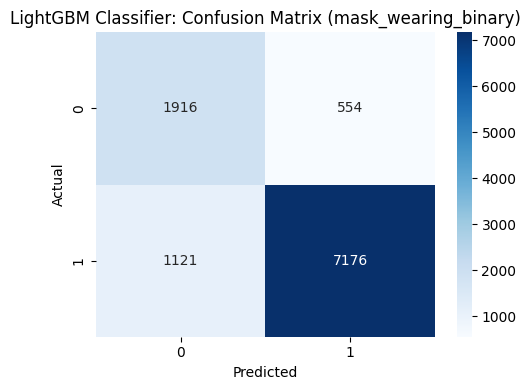

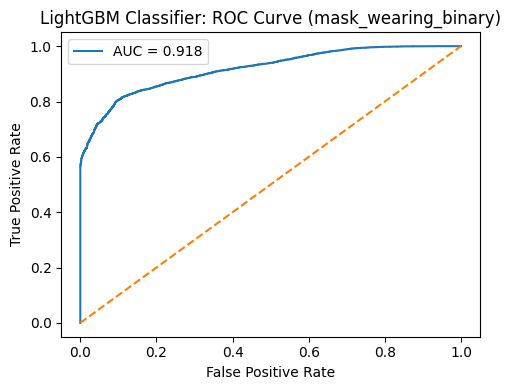

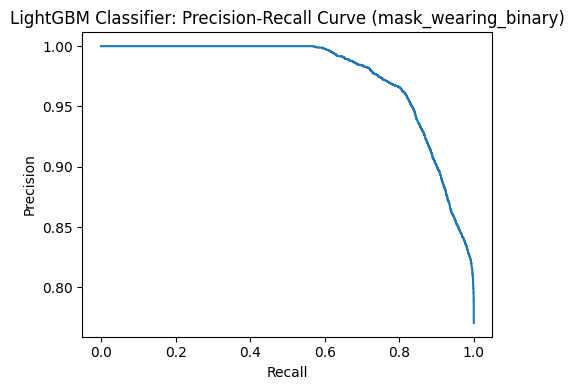

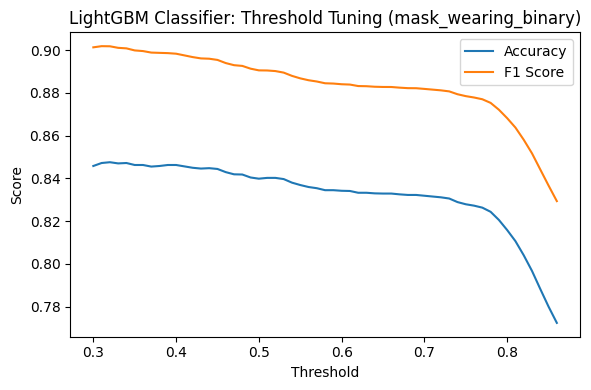

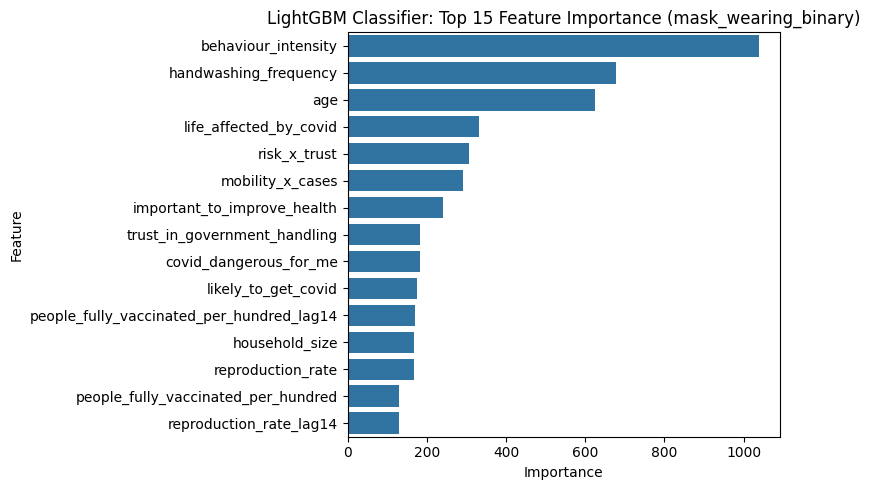


LightGBM plots for: wash_hands_binary


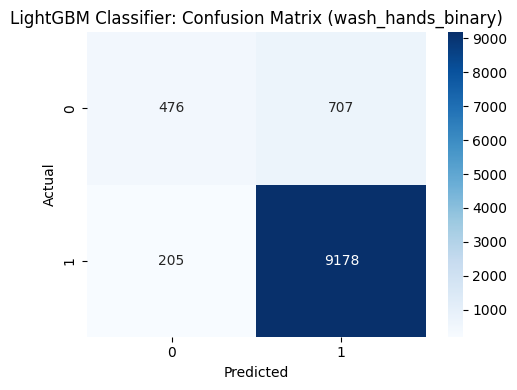

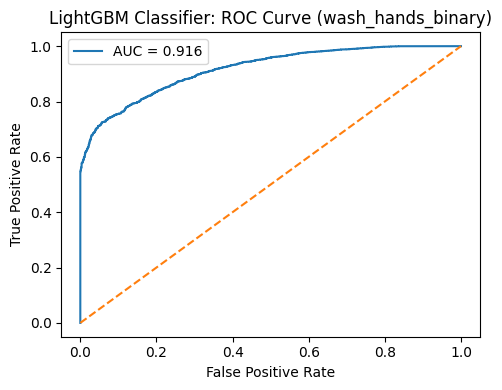

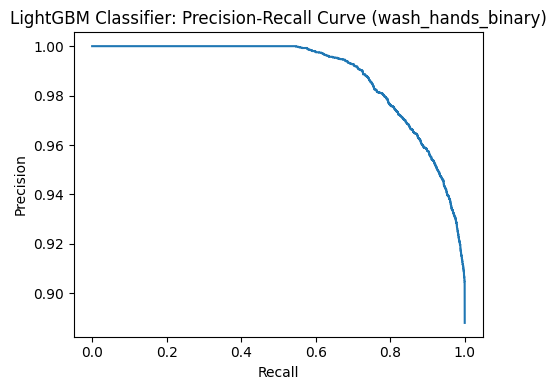

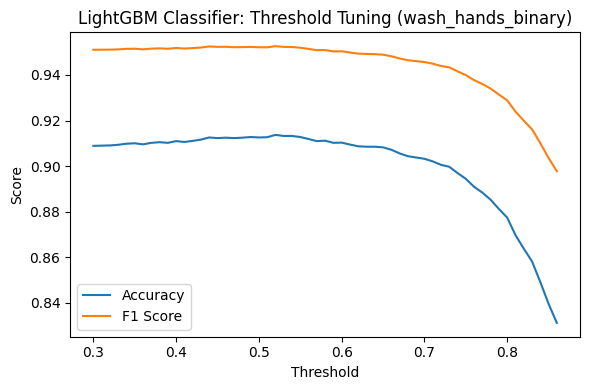

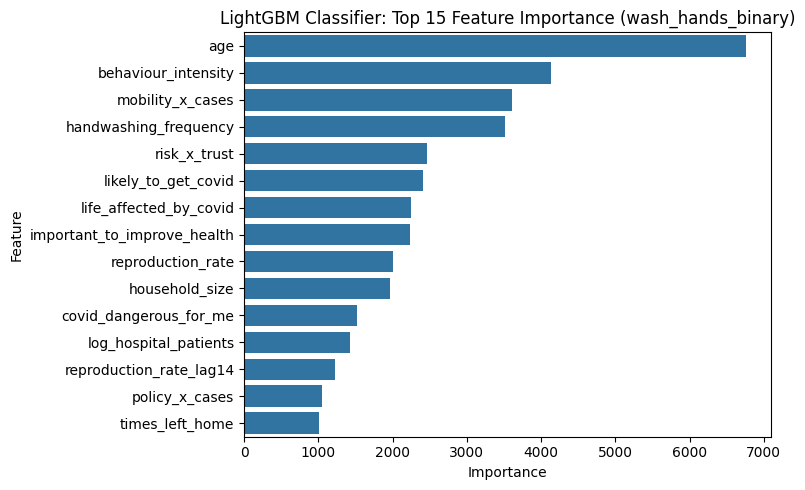


LightGBM plots for: use_sanitiser_binary


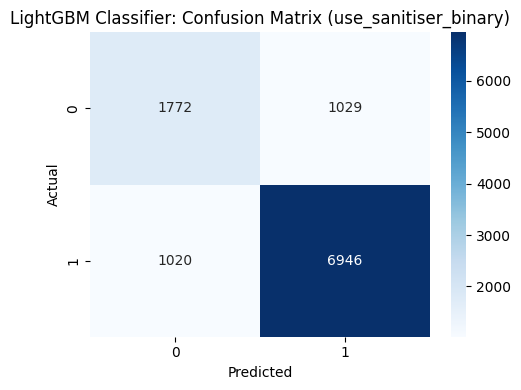

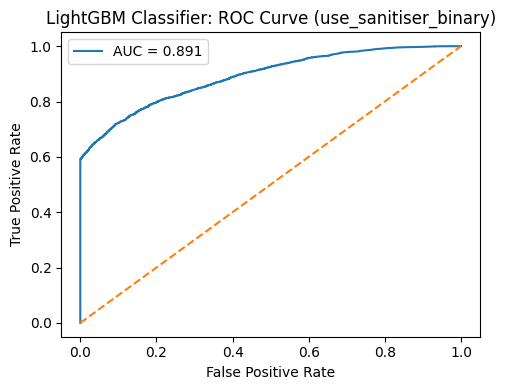

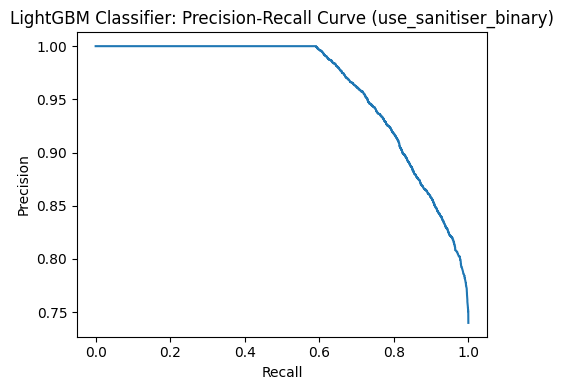

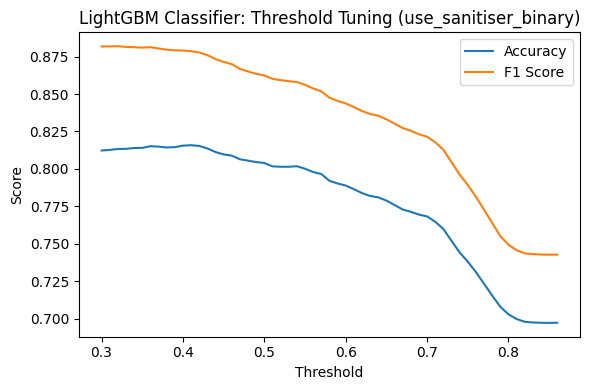

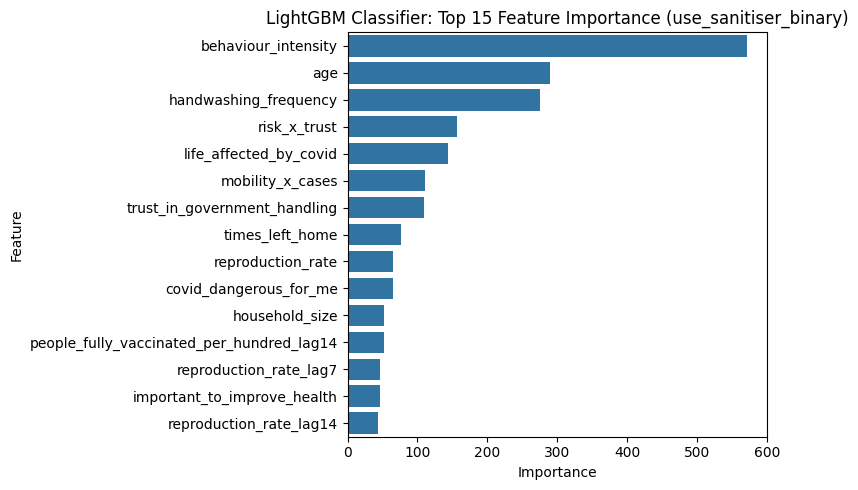


LightGBM plots for: avoid_going_out_binary


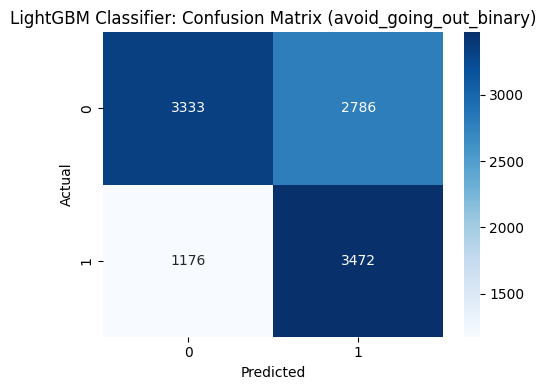

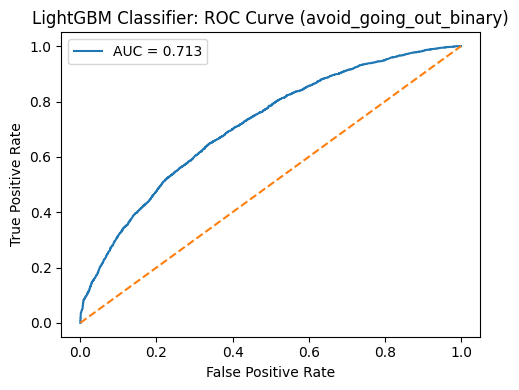

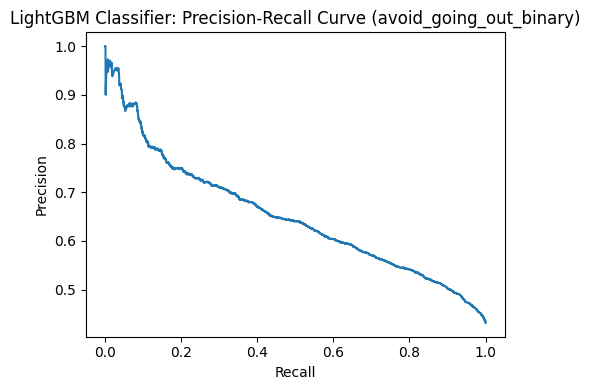

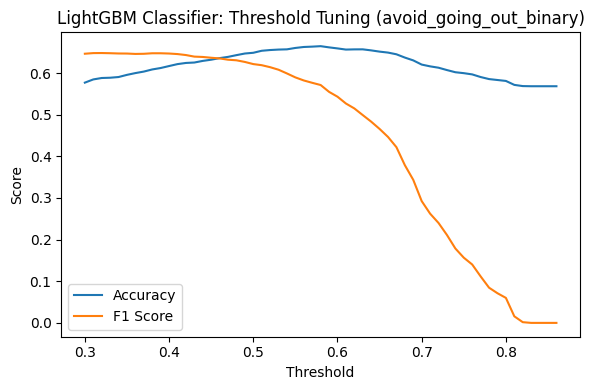

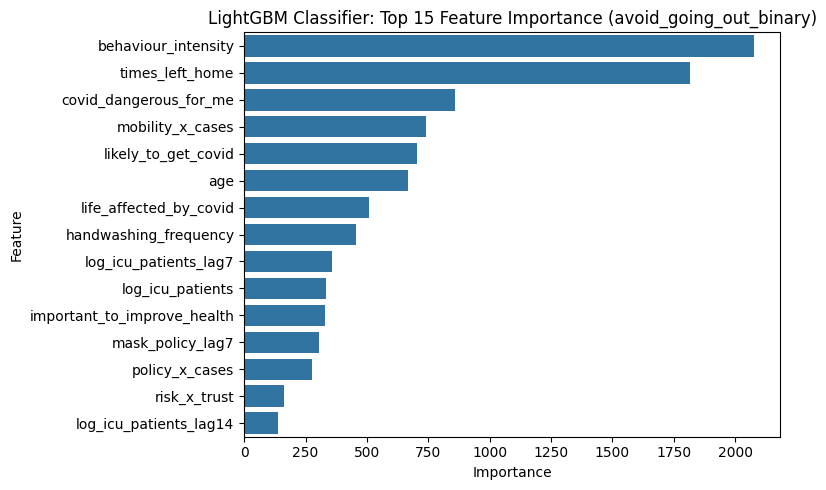


LightGBM plots for: avoid_public_transport_binary


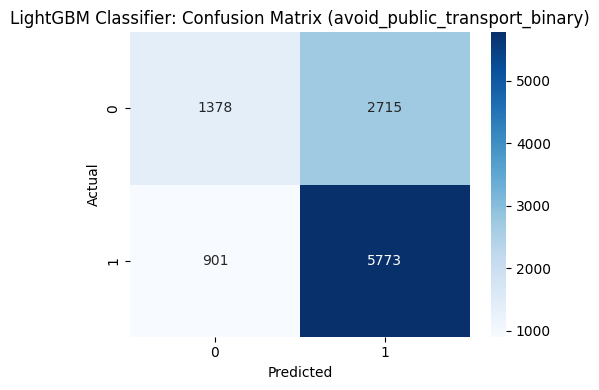

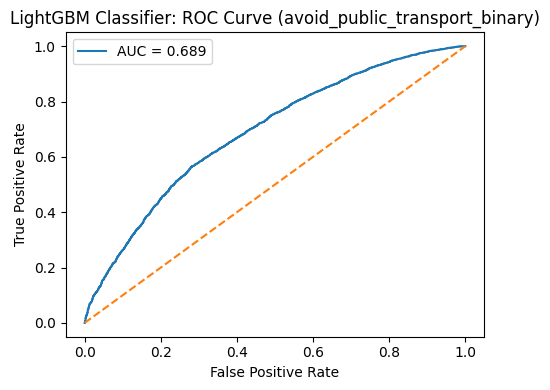

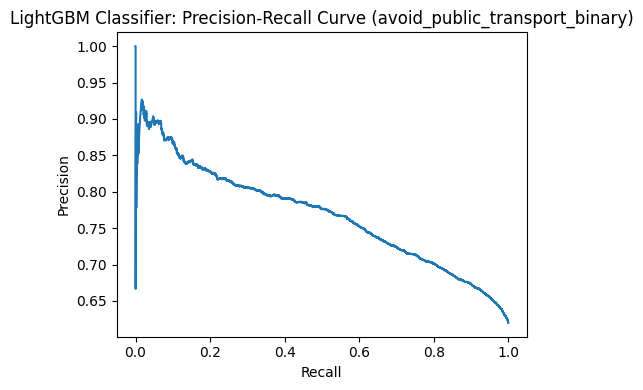

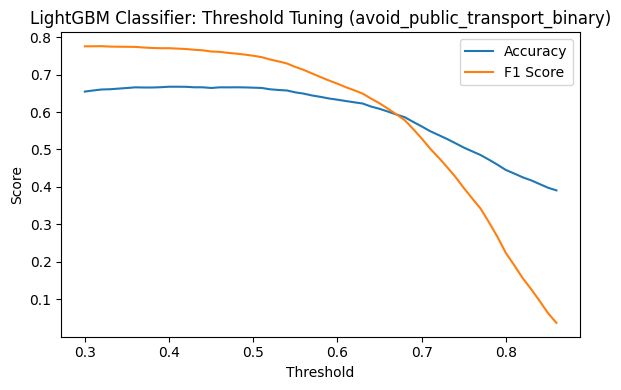

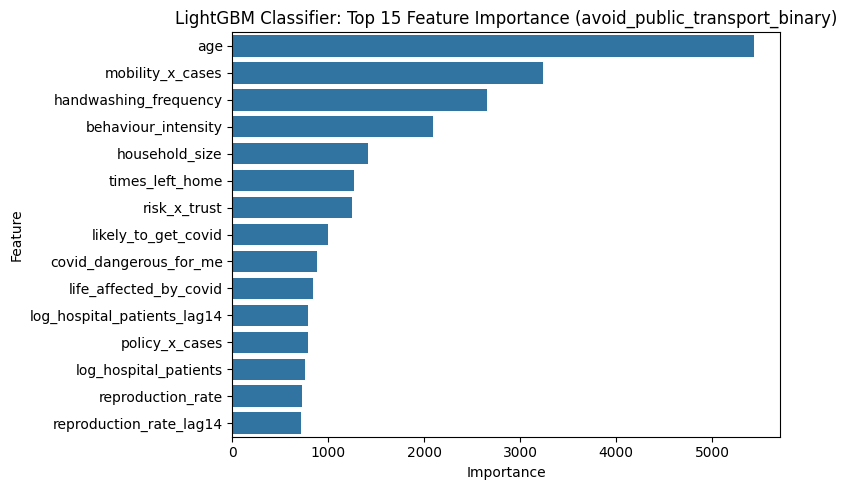


LightGBM plots for: avoid_crowded_areas_binary


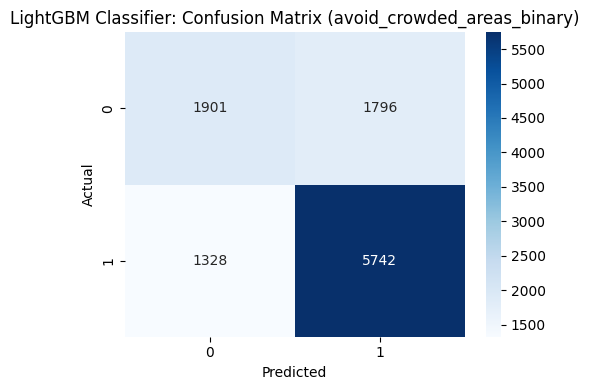

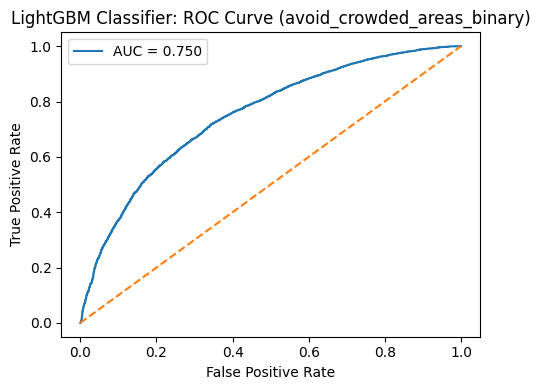

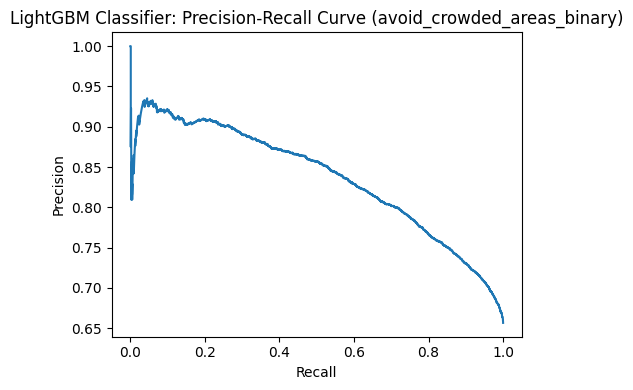

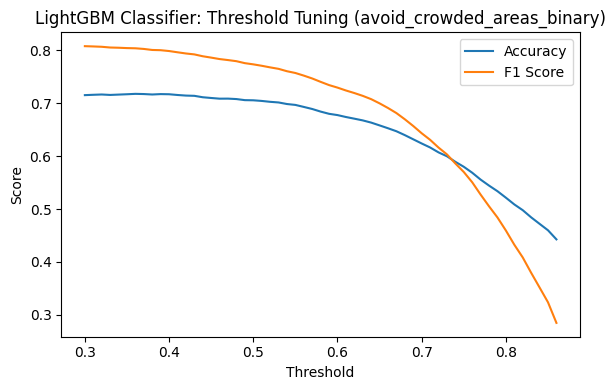

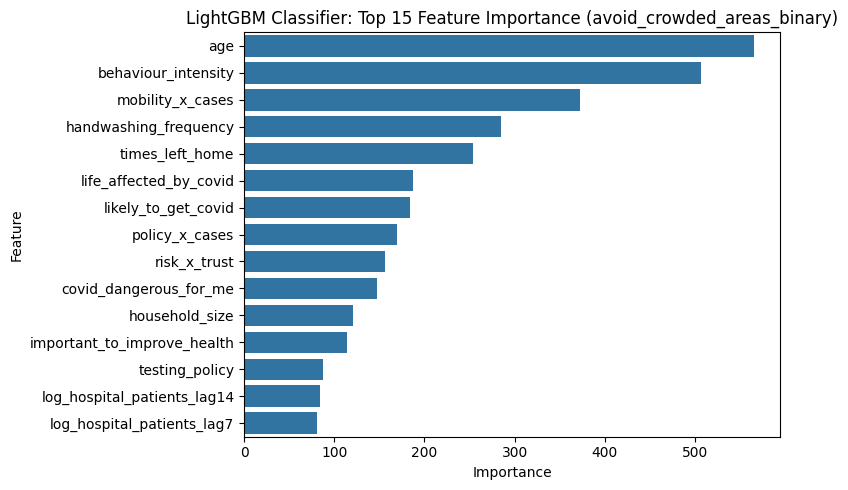


LightGBM plots for: would_self_isolate_binary


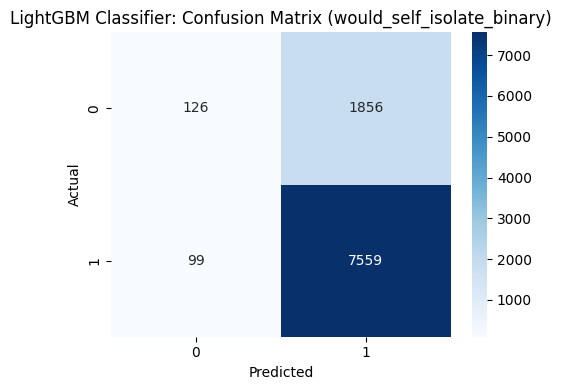

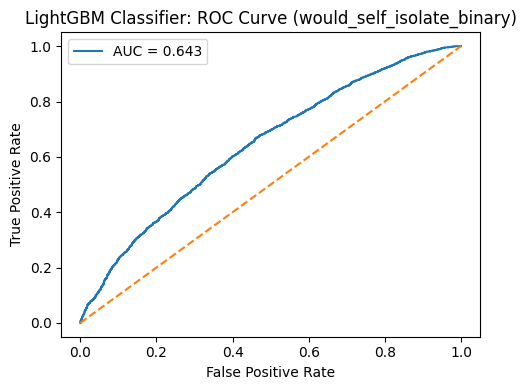

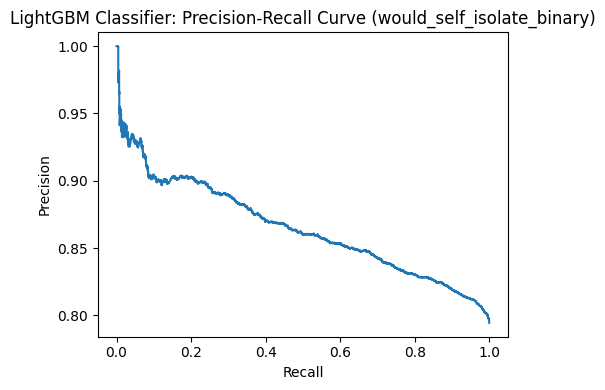

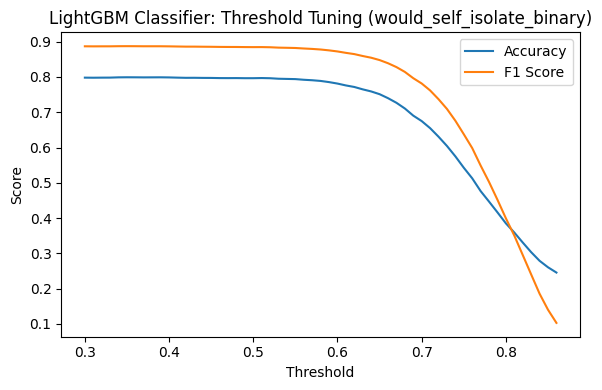

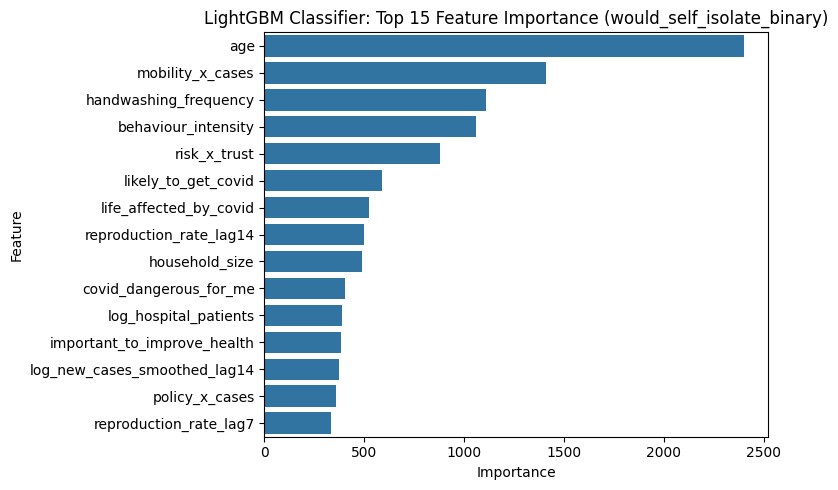


LightGBM plots for: willingness_self_isolate_binary


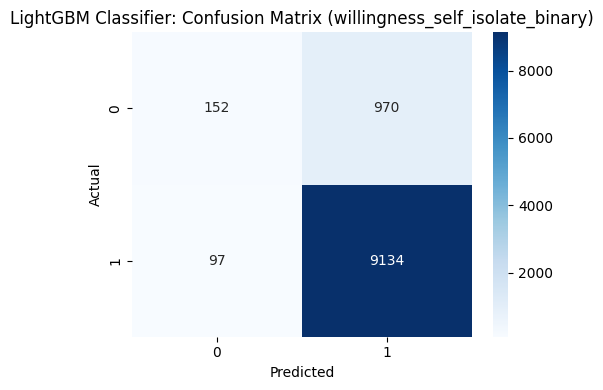

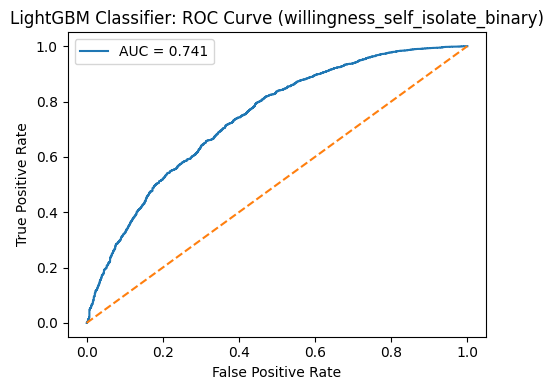

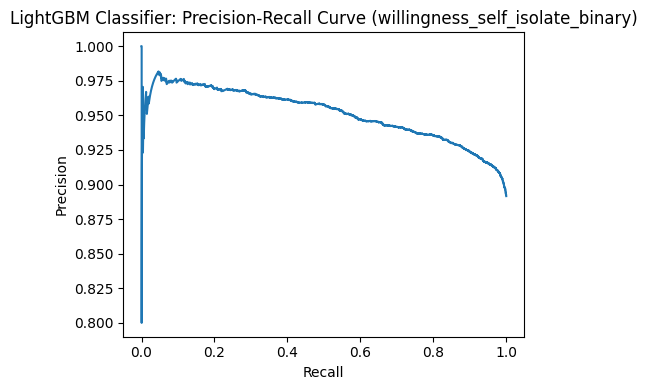

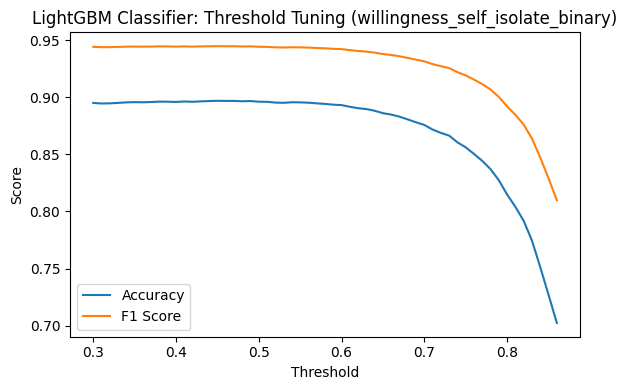

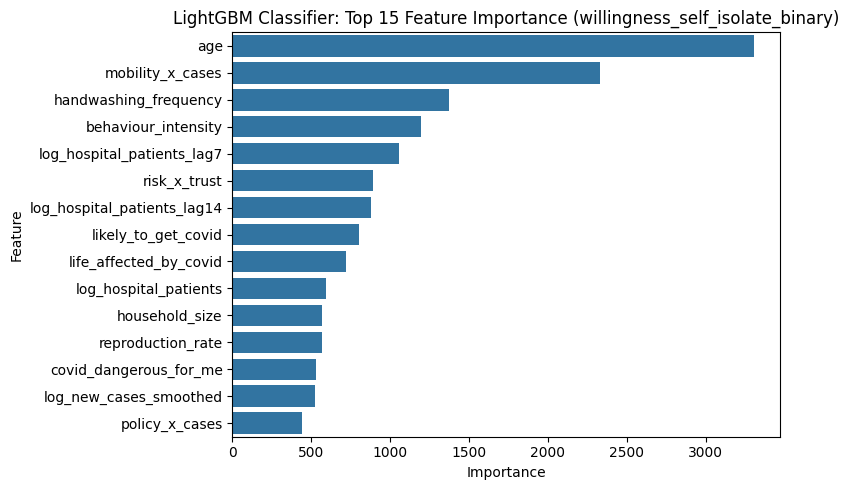

In [25]:
# LightGBM plots for all Y variables
for target in y_vars_binary:
    print(f"\nLightGBM plots for: {target}")

    plotter.plot_all_for_one_model(
        model=lightgbm_clf_models[target],
        importance_df=lightgbm_clf_importance[target],
        target=target,
        model_name="LightGBM Classifier"
    )


CatBoost plots for: mask_wearing_binary


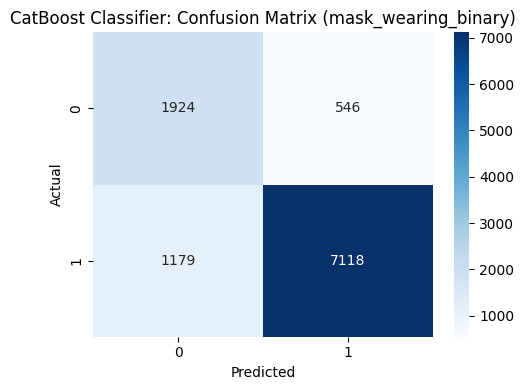

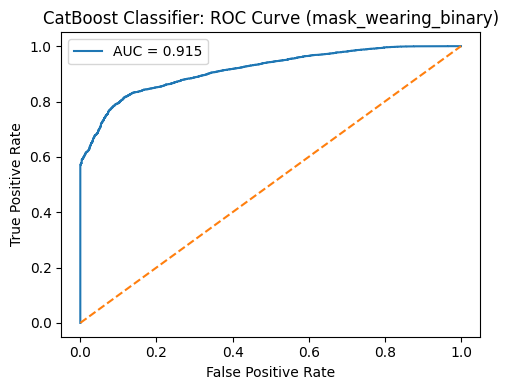

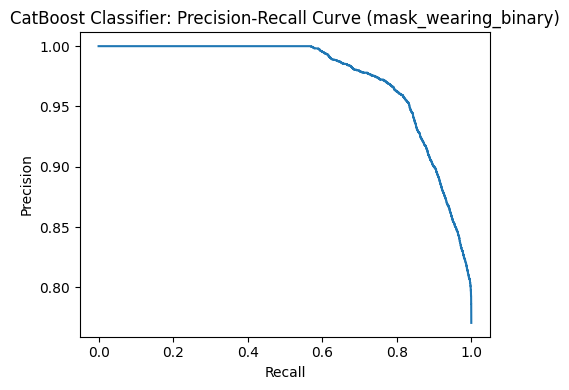

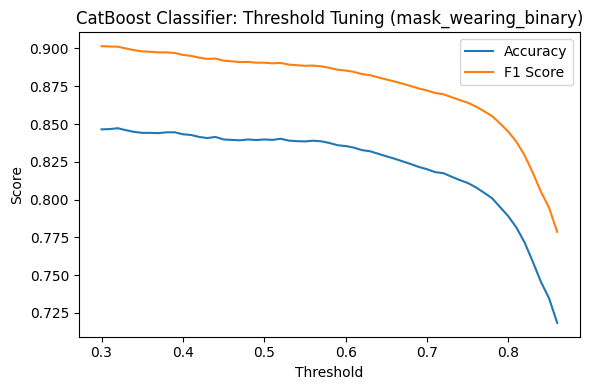

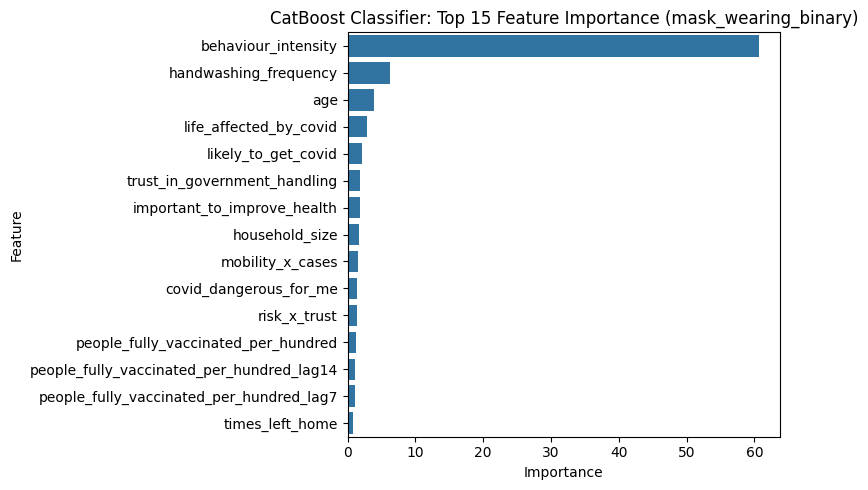


CatBoost plots for: wash_hands_binary


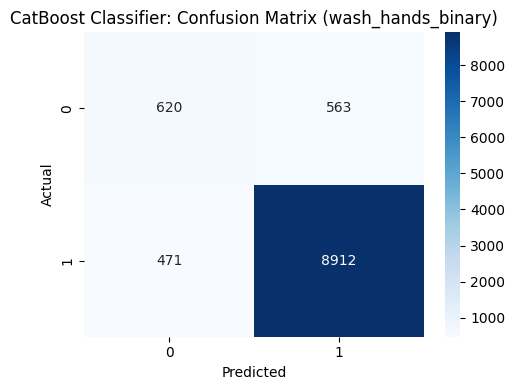

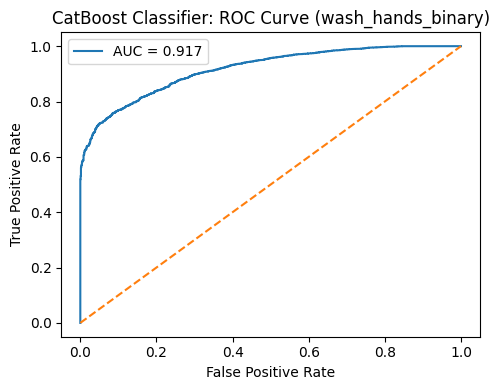

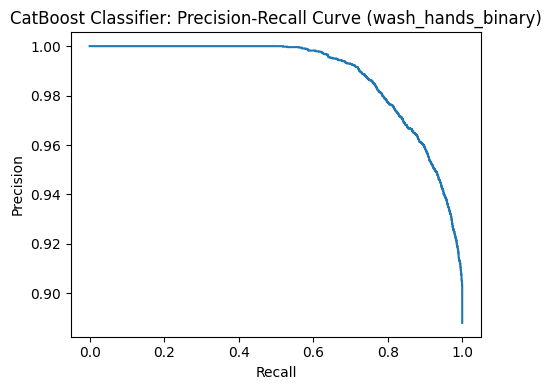

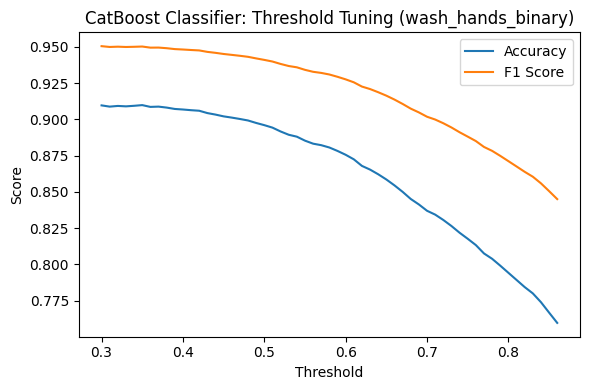

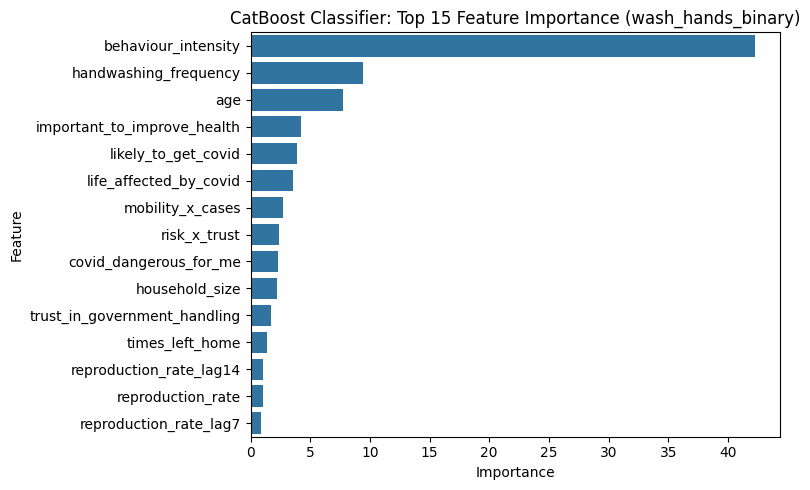


CatBoost plots for: use_sanitiser_binary


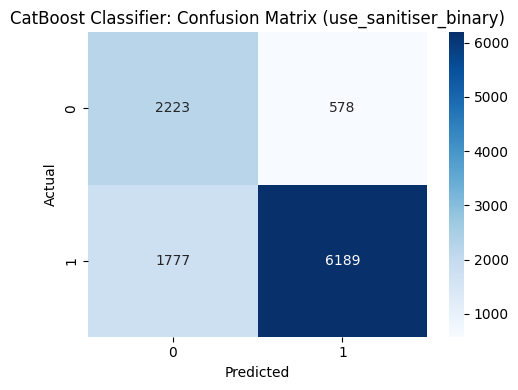

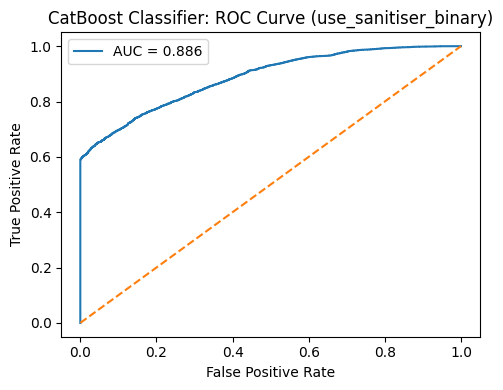

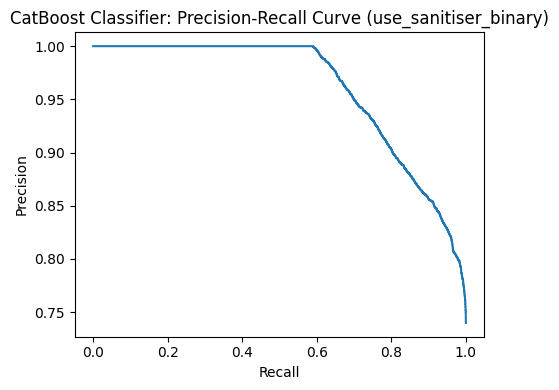

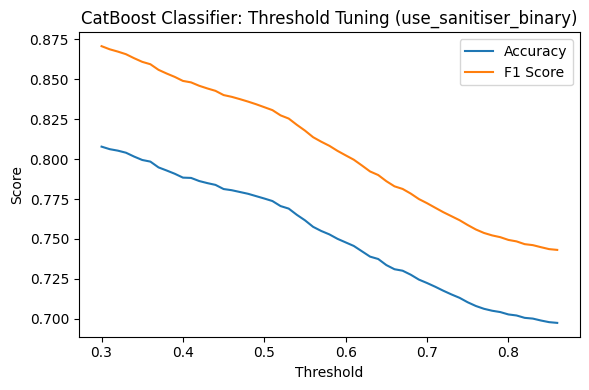

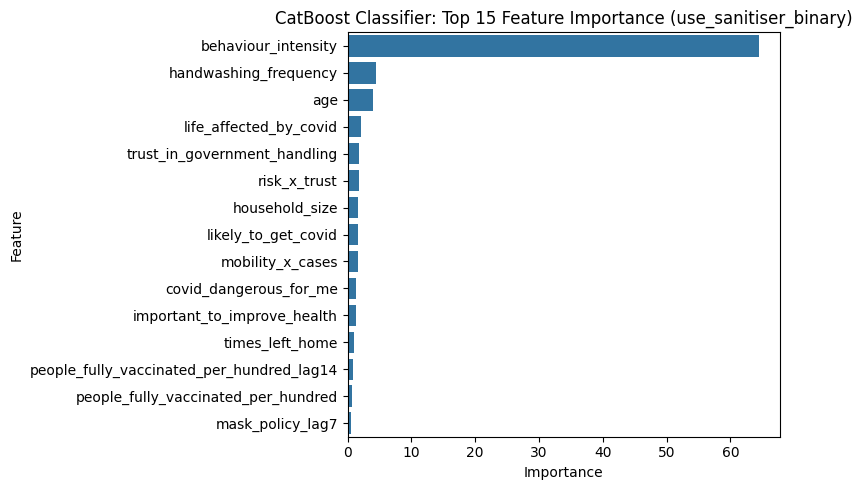


CatBoost plots for: avoid_going_out_binary


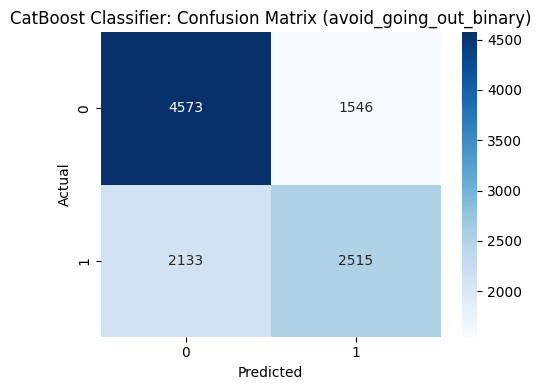

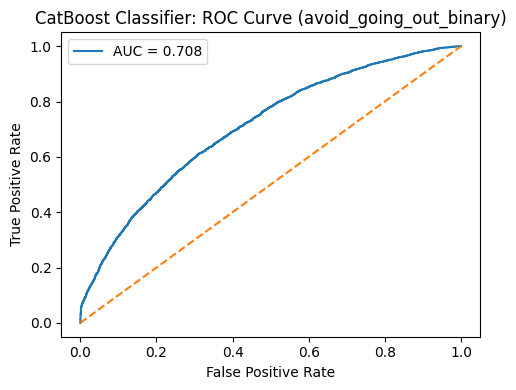

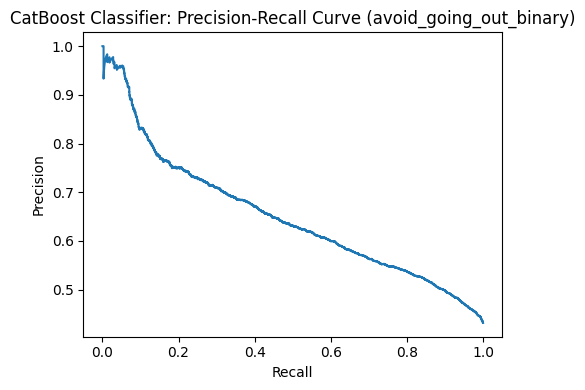

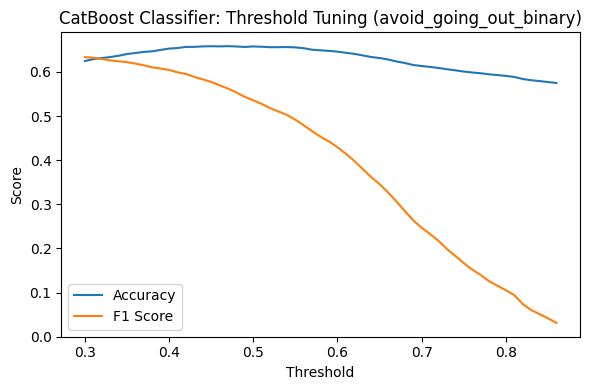

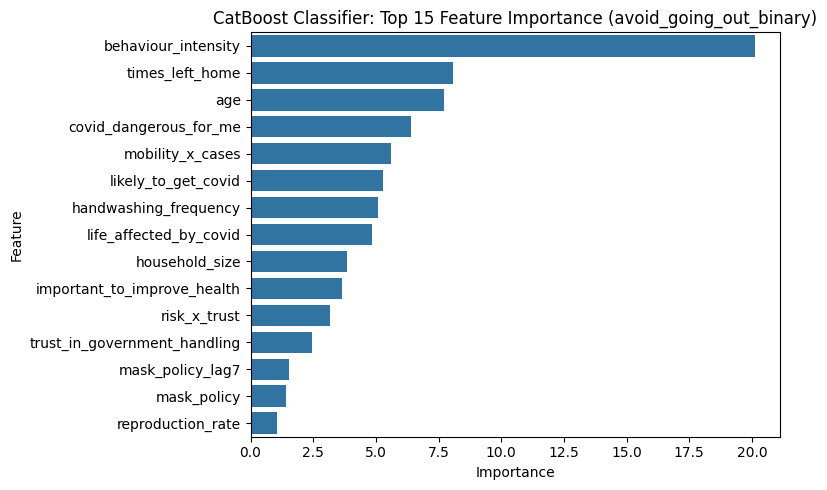


CatBoost plots for: avoid_public_transport_binary


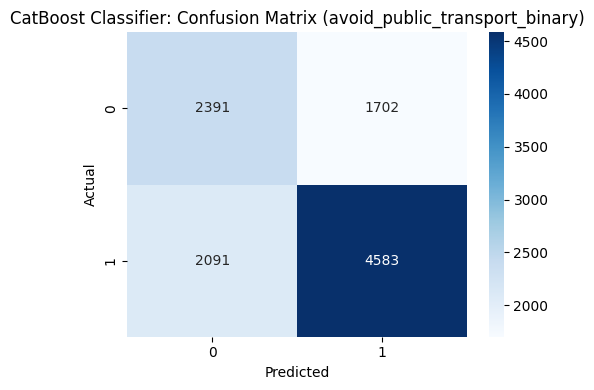

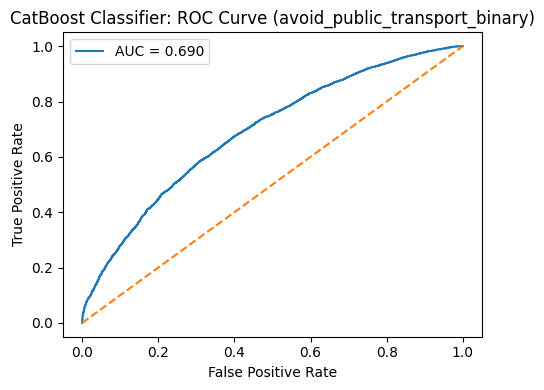

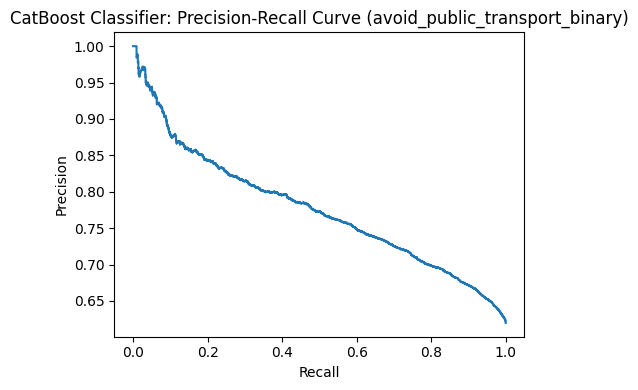

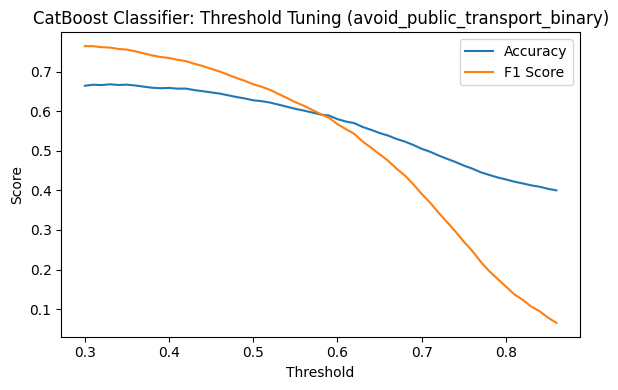

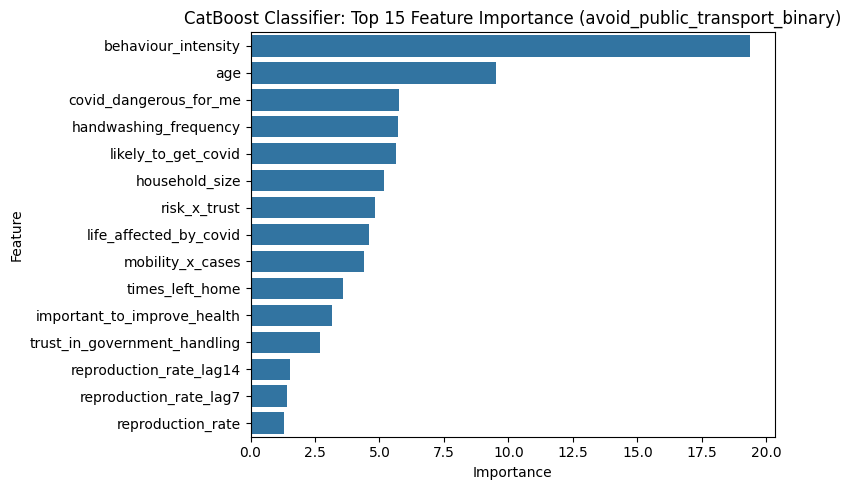


CatBoost plots for: avoid_crowded_areas_binary


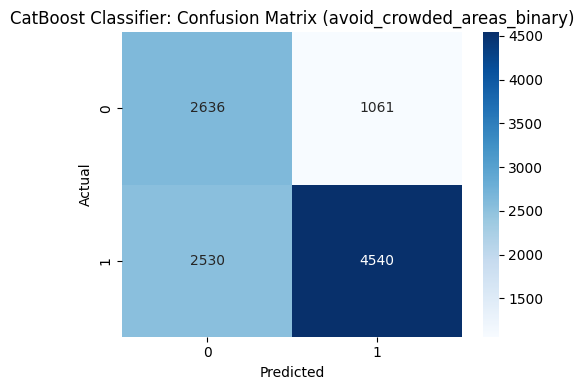

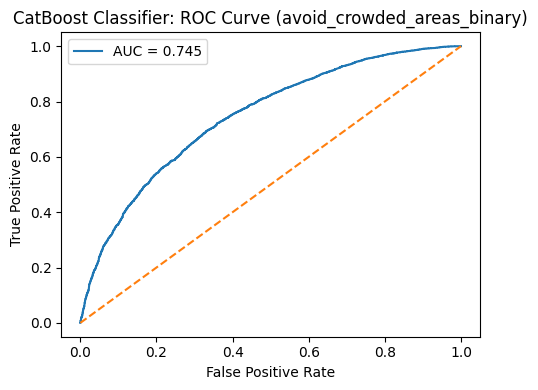

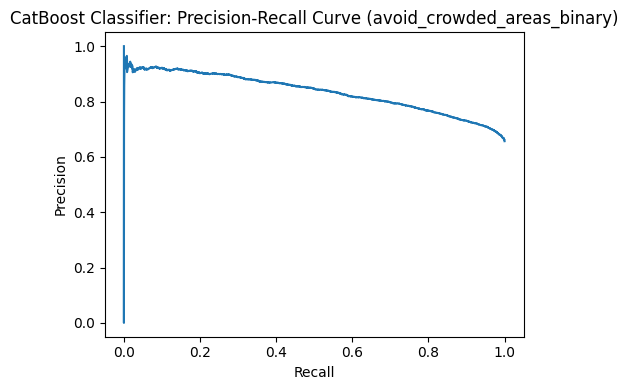

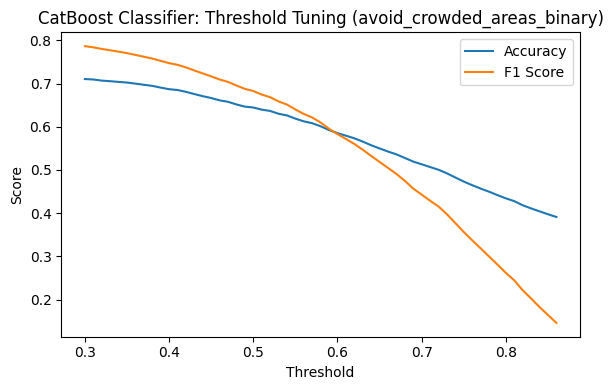

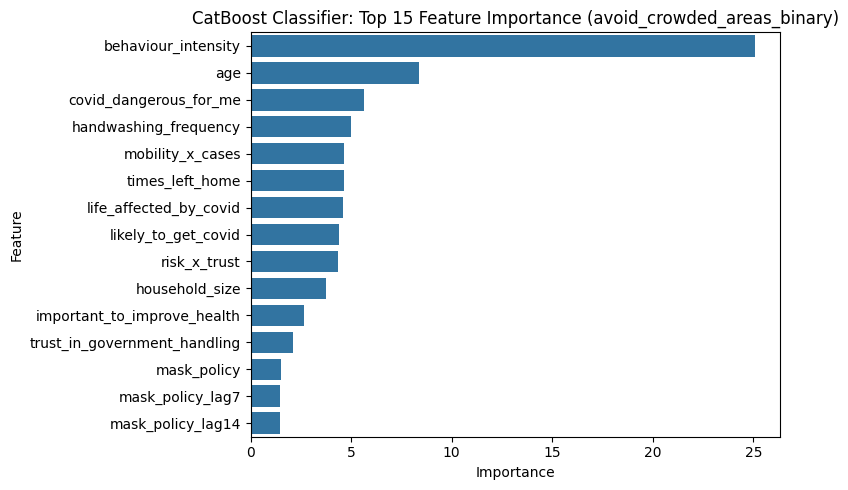


CatBoost plots for: would_self_isolate_binary


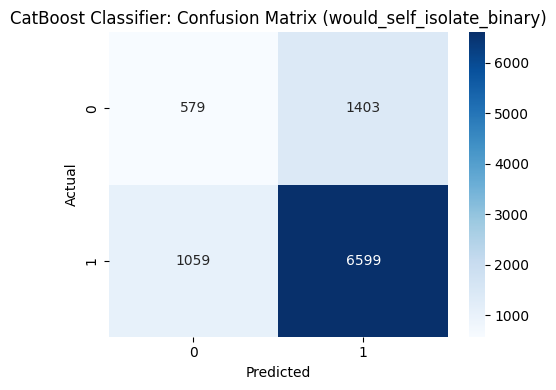

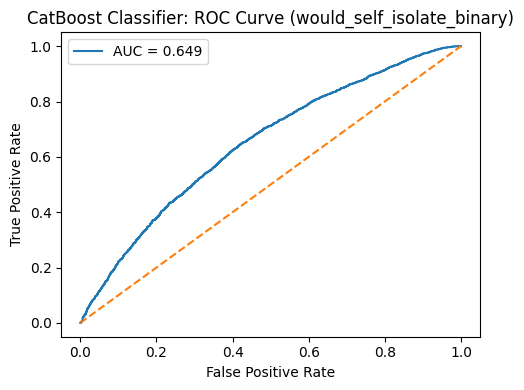

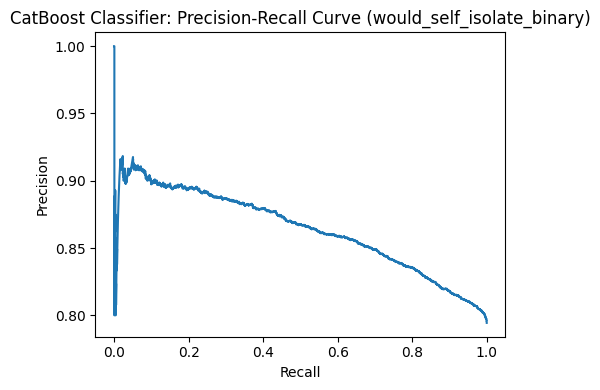

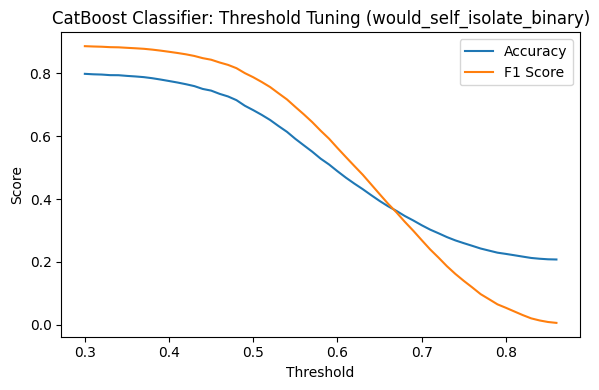

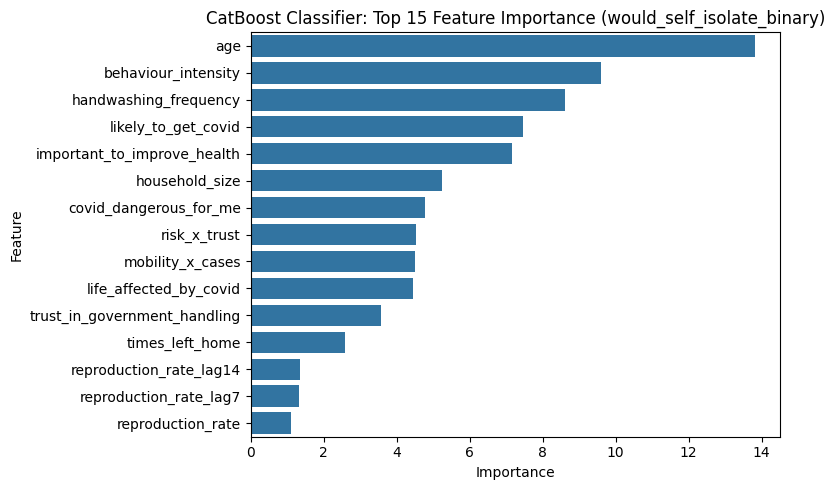


CatBoost plots for: willingness_self_isolate_binary


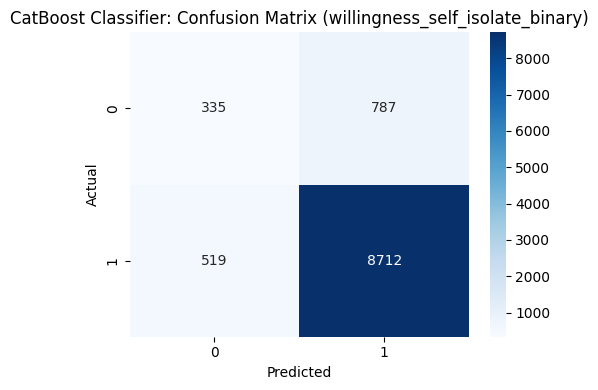

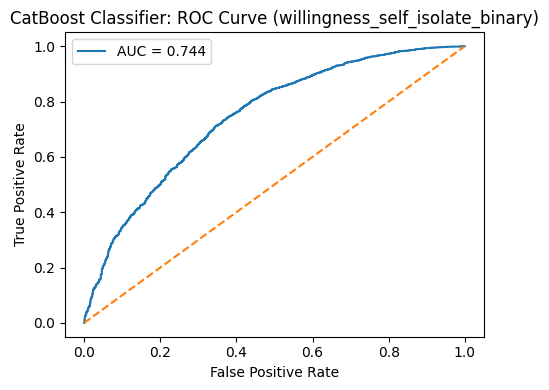

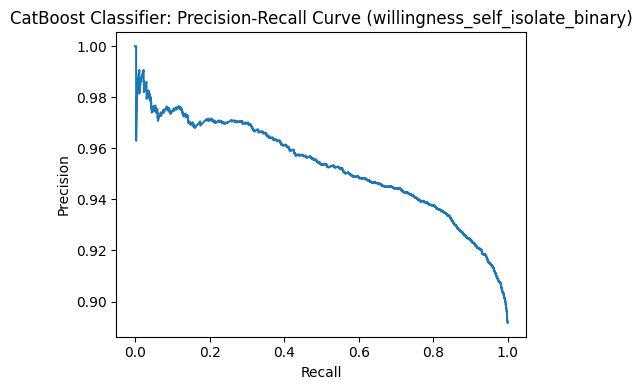

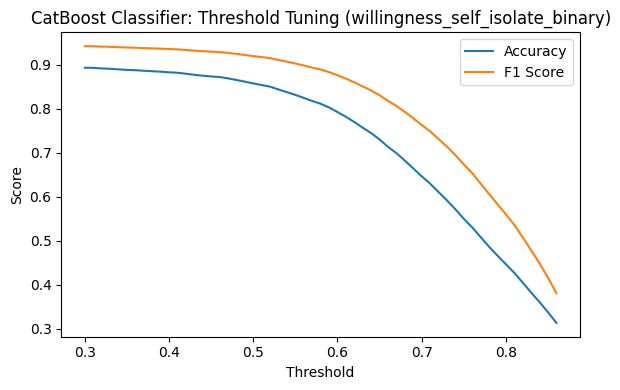

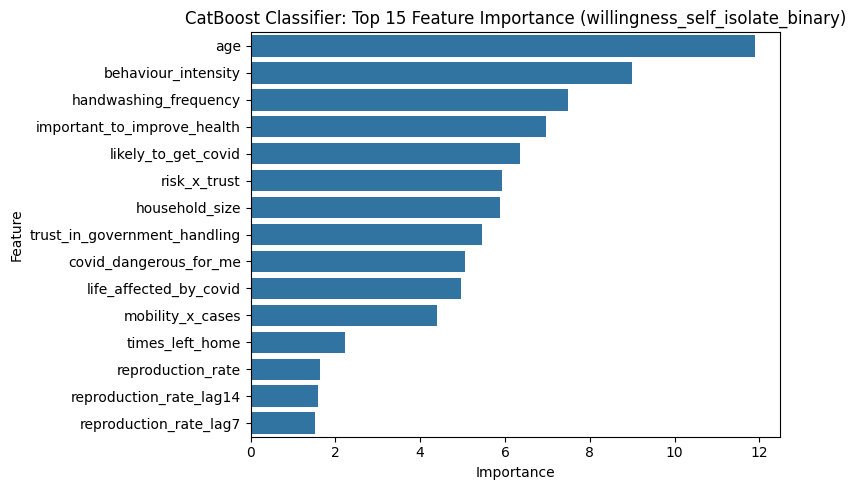

In [26]:
# CatBoost plots for all Y variables
for target in y_vars_binary:
    print(f"\nCatBoost plots for: {target}")

    plotter.plot_all_for_one_model(
        model=catboost_clf_models[target],
        importance_df=catboost_clf_importance[target],
        target=target,
        model_name="CatBoost Classifier"
    )